# Generate Stratigraphic Column for County

This script builds a stratigraphic column diagram from a USGS GeMS (Geologic Map Schema) map-units shapefile and a DEM, and saves it as a PNG (plus a CSV of the underlying numbers for transparency/QA).

WHAT IT DOES
------------
1. Reads the GeMS units polygon shapefile.
2. Dissolves polygons by map unit code (a unit is often mapped as several
   separate outcrop patches).
3. For each unit, samples the DEM within its outcrop footprint to get
   min/max/mean elevation, and uses (max - min) as an *apparent* thickness.
4. Orders units stratigraphically (oldest at the bottom) using, in order of
   preference: an explicit stratigraphic-order field (e.g. GeMS
   HierarchyKey), a numeric age field, or -- as a last-resort fallback --
   relative elevation.
5. Colors each unit using its GeMS AreaFillRGB attribute if present,
   otherwise the standard USGS/CGMW geologic-period color (see the
   companion gems_period_color_join.py script), otherwise neutral gray.
6. Draws a stacked-rectangle column with matplotlib and writes it to PNG.

IMPORTANT CAVEAT -- READ THIS
------------------------------
"Apparent thickness" here is just (max elevation - min elevation) of the
ground surface within each unit's mapped outcrop. That is NOT the true
stratigraphic thickness of the unit unless the beds are flat-lying and the
land surface cuts cleanly across the full unit. For dipping strata, true
thickness depends on outcrop width, dip, and topographic slope -- none of
which can be reliably derived from a units polygon + DEM alone without a
structural cross-section or dip/strike data. Treat the resulting column as
a *schematic, relative* diagram (useful for sequence/order and rough
relative thickness), not a measured section. An optional, heavily-caveated
dip correction is available via --dip-field if your shapefile carries a
per-unit average dip in degrees; even then, treat results as approximate.

USAGE
-----
Edit the CONFIG section directly below the imports with your file paths and
field names, then just run:

    python GenStratColCo.py

Command-line arguments are also supported and, if given, override the
CONFIG values -- so you can leave CONFIG set up for your usual project and
still point at a different file one-off from the command line:

    python GenStratColCo.py units.shp dem.tif output_column.png \
        --unit-field MapUnit --order-field HierarchyKey

REQUIRES: geopandas, rasterio, numpy, matplotlib, shapely

Created by Ryan Lennon on 9/10/2026

E-mail:
ryanlennon {at} proton {dot} me

Directory '/Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs' already exists.
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/OkanoganCounty_GeMS.shp ...
  30 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Carboniferous and Permian volcanic rocks: #67A599 (period match on 'Carboniferous and Permian volcanic rocks')
  Cretaceous nonmarine rocks: #7FC64E (period match on 'Cretaceous nonmarine rocks')
  Cretaceous sedimentary rocks, mostly marine: #7FC64E (period match on 'Cretaceous sedimentary rocks, mostly marine')
  Eocene-Oligocene volcanic rocks: #FD9A52 (period match

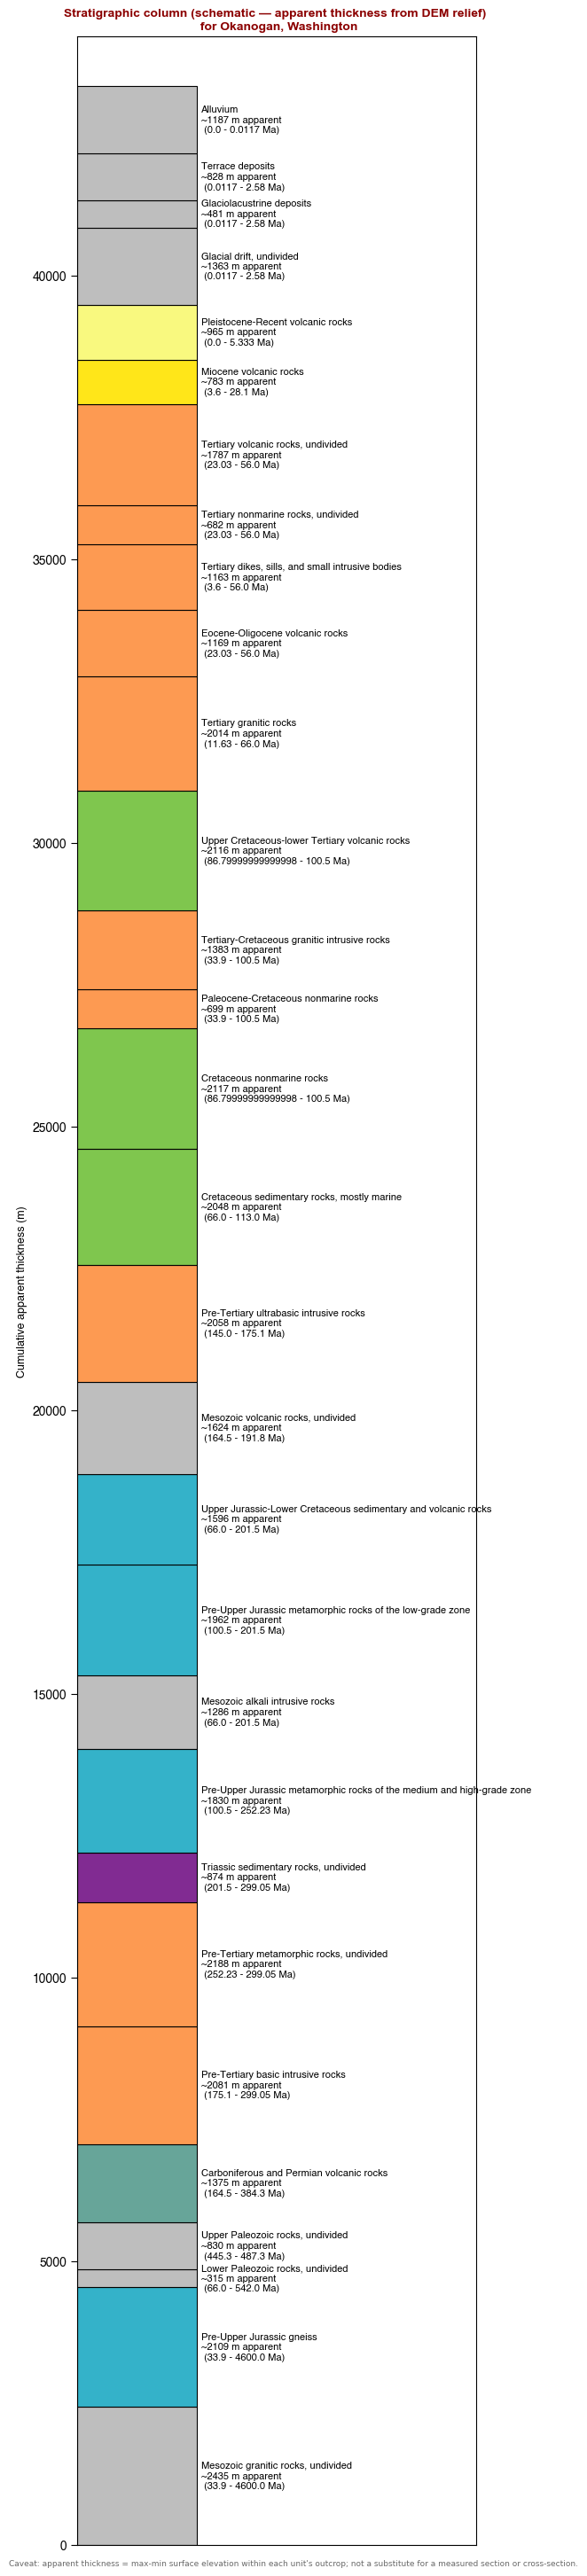

In [6]:
import argparse
import re
import sys
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.patches import Rectangle
from rasterio.mask import mask as rio_mask
import pandas as pd

# ===========================================================================
# CONFIG -- edit these for your project, then just run the script with no
# command-line arguments. Anything left as None/empty falls back to the
# argparse default shown in main() below.
# ===========================================================================

county = "Okanogan"
state_name = "Washington"
geo_dir = '/Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS'
srtm_dir = '/Users/ryanlennon/Dropbox/Terrain/SRTM'

# Read State FIPS codes table and subset by state name
states_df = pd.read_csv('https://gist.githubusercontent.com/ryanmichaellennon/f1858673bbf88009b7819c4907776652/raw/11d15233327c8080c9646c7e1f23052659db251d/us-state-ansi-fips.csv')
state_df = states_df[states_df['stname']==state_name]
state_info = state_df.iloc[0]
state_usps = state_info[' stusps']
state_fips = state_info[' st']
state_abb = state_usps.replace(' ','')
GeMS_dir = os.path.join(geo_dir,state_name)
srtm_state_dir = os.path.join(srtm_dir,state_name)
county_fn = county.replace(" ", "") + '.shp'
GeMS_fn = county.replace(" ", "") + 'County_GeMS.shp'
DEM_fn = county.replace(" ", "") + " County_SRTM.tiff"
# Create the directory to put outputs
SC_dir = os.path.join(GeMS_dir,'Stratigraphs')
try:
    os.mkdir(SC_dir)
    print(f"Directory '{SC_dir}' created successfully.")
except FileExistsError:
    print(f"Directory '{SC_dir}' already exists.")
except PermissionError:
    print(f"Permission denied: Unable to create '{SC_dir}'.")
except Exception as e:
    print(f"An error occurred: {e}")
    
SC_fn = county.replace(" ", "") + '_stratigraphy.png'
CSV_fn = county.replace(" ", "") + '_stratigraphy.csv'
# --- Required paths ---
UNITS_SHAPEFILE = os.path.join(GeMS_dir,GeMS_fn)       # path to GeMS map-units polygon shapefile (.shp)
units_shapefile = UNITS_SHAPEFILE
DEM_PATH = os.path.join(srtm_state_dir,DEM_fn)                # path to DEM raster (e.g. GeoTIFF)
output_png = os.path.join(SC_dir,SC_fn)  # where to save the column figure

# --- Optional: also write the underlying data table ---
csv_out = os.path.join(SC_dir,CSV_fn)  # set to None to skip writing a CSV

# --- Attribute field names (edit to match your shapefile's schema) ---
unit_field = "UNIT_NAME"        # unit code field
label_field = "Label"        # short label field
name_field = "FullName"       # full unit name field
order_field = "HierarchyKey"  # stratigraphic order field (GeMS default: HierarchyKey)
age_field = "MAX_MA"           # numeric age field in Ma, used if ORDER_FIELD is absent
color_field = "AreaFillRGB"   # GeMS official unit color field
period_field = "UNIT_NAME"       # geologic period field, used as color fallback
ageran_field = "RANGE_LAB"

# --- Ordering convention ---
# True: smaller ORDER_FIELD values = younger units (GeMS HierarchyKey convention).
# Set to False to invert.
youngest_first = True


# ===========================================================================


# ---------------------------------------------------------------------------
# Standard geologic period colors (CGMW/USGS geologic time scale palette),
# used as a fallback when a unit has no explicit AreaFillRGB color.
# Kept identical to gems_period_color_join.py for consistency.
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Standard geologic period colors (CGMW/USGS geologic time scale palette),
# used as a fallback when a unit has no explicit AreaFillRGB color.
# Kept identical to gems_period_color_join.py for consistency.
# ---------------------------------------------------------------------------
STANDARD_PERIOD_COLORS = {
    "Quaternary":     "#F9F97F",
    "Neogene":        "#FFE619",
    "Paleogene":      "#FD9A52",
    "Cretaceous":     "#7FC64E",
    "Jurassic":       "#34B2C9",
    "Triassic":       "#812B92",
    "Permian":        "#F04028",
    "Pennsylvanian":  "#67A599",
    "Mississippian":  "#5DA0A6",
    "Devonian":       "#CB8C37",
    "Silurian":       "#B3E1B6",
    "Ordovician":     "#009270",
    "Cambrian":       "#7FA056",
    "Proterozoic":    "#F74370",
    "Archean":        "#F0047F",
    "Hadean":         "#FF6A8C",
}

PERIOD_ALIASES = {
    "carboniferous": "Pennsylvanian",
    "quaternary": "Quaternary", "holocene": "Quaternary", "pleistocene": "Quaternary",
    "neogene": "Neogene", "pliocene": "Neogene", "miocene": "Neogene",
    "paleogene": "Paleogene", "oligocene": "Paleogene", "eocene": "Paleogene", "paleocene": "Paleogene",
    "tertiary": "Paleogene",
    "cretaceous": "Cretaceous", "jurassic": "Jurassic", "triassic": "Triassic",
    "permian": "Permian", "pennsylvanian": "Pennsylvanian", "mississippian": "Mississippian",
    "devonian": "Devonian", "silurian": "Silurian", "ordovician": "Ordovician", "cambrian": "Cambrian",
    "proterozoic": "Proterozoic", "mesoproterozoic": "Proterozoic", "neoproterozoic": "Proterozoic",
    "paleoproterozoic": "Proterozoic",
    "archean": "Archean", "mesoarchean": "Archean", "neoarchean": "Archean",
    "paleoarchean": "Archean", "eoarchean": "Archean",
    "hadean": "Hadean", "precambrian": "Proterozoic",
}
_ALIAS_PATTERN = re.compile(
    r"\b(" + "|".join(sorted(PERIOD_ALIASES.keys(), key=len, reverse=True)) + r")\b",
    re.IGNORECASE,
)

DEFAULT_COLOR = "#BEBEBE"


def first_valid(values):
    """
    Return the first usable (non-null, non-blank) value from an iterable of
    raw attribute values, or None if every value is missing/blank.

    This exists specifically to avoid a subtle bug: geopandas' dissolve()
    aggregates non-geometry columns with aggfunc="first" by default, which
    means it literally keeps whichever row happens to come first in the
    table -- even if that row has a blank/NaN attribute and a later row
    for the same unit has the real value filled in. Units mapped as many
    scattered small polygons (Quaternary surficial deposits are the classic
    case) are disproportionately likely to have their PERIOD/color pulled
    from an incomplete row this way, silently producing a wrong or default
    gray color even though the correct period is sitting right there in
    another row for the same unit. Scanning for the first genuinely valid
    value fixes that.
    """
    for v in values:
        if v is None:
            continue
        if isinstance(v, float) and np.isnan(v):
            continue
        text = str(v).strip().strip("\x00")
        if text == "" or text.lower() in ("none", "nan", "null"):
            continue
        return v
    return None


# Common single/double-letter USGS geologic-map age-symbol codes, used as a
# last-resort match when a field stores an abbreviation (e.g. a MapUnit
# prefix convention) rather than a full period name.
PERIOD_LETTER_CODES = {
    "Q": "Quaternary",
    "T": "Paleogene",     # legacy "Tertiary" symbol; ambiguous, defaults to Paleogene
    "N": "Neogene",
    "PG": "Paleogene",
    "K": "Cretaceous",
    "J": "Jurassic",
    "TR": "Triassic",
    "P": "Permian",
    "IP": "Pennsylvanian",
    "M": "Mississippian",
    "D": "Devonian",
    "S": "Silurian",
    "O": "Ordovician",
    "C": "Cambrian",
    "PC": "Proterozoic",   # common "pC" / "p€" Precambrian symbol
}


def match_period_color(raw_value):
    """
    Match a raw PERIOD-field value to its standard color. Tries, in order:
    1. An exact (case/whitespace-insensitive) match against a canonical
       period name.
    2. A whole-word alias match anywhere in the string (handles values like
       'Late Cretaceous', 'Eocene-Oligocene', 'Precambrian').
    3. A standard USGS one/two-letter age-symbol code (handles values like
       'Q', 'Kss'-style MapUnit prefixes if that's what ended up in the
       field).
    Returns a '#RRGGBB' hex string, or None if nothing matched.
    """
    if raw_value is None:
        return None
    text = str(raw_value).strip().strip("\x00")
    if not text:
        return None

    for canonical, hexval in STANDARD_PERIOD_COLORS.items():
        if text.lower() == canonical.lower():
            return hexval

    m = _ALIAS_PATTERN.search(text)
    if m:
        return STANDARD_PERIOD_COLORS[PERIOD_ALIASES[m.group(1).lower()]]

    code = re.sub(r"[^A-Za-z]", "", text).upper()
    if code in PERIOD_LETTER_CODES:
        return STANDARD_PERIOD_COLORS[PERIOD_LETTER_CODES[code]]

    return None


def parse_area_fill_rgb(raw_value):
    """
    GeMS DescriptionOfMapUnits.AreaFillRGB is typically a string like
    '255,235,190' (comma-separated R,G,B, 0-255). Be tolerant of
    semicolon/space separators too. Returns a '#RRGGBB' hex string or None.
    """
    if raw_value is None:
        return None
    text = str(raw_value).strip()
    if not text:
        return None
    parts = re.split(r"[,;\s]+", text)
    parts = [p for p in parts if p != ""]
    if len(parts) != 3:
        return None
    try:
        r, g, b = (int(float(p)) for p in parts)
    except ValueError:
        return None
    if not all(0 <= v <= 255 for v in (r, g, b)):
        return None
    return f"#{r:02X}{g:02X}{b:02X}"


def zonal_min_max_mean(dem_path, geometry, dem_crs):
    """Sample a DEM within a (multi)polygon geometry; return (min, max, mean)
    of valid (non-nodata) pixels, or (None, None, None) if nothing valid."""
    with rasterio.open(dem_path) as src:
        try:
            out_image, _ = rio_mask(src, [geometry.__geo_interface__], crop=True, filled=True)
        except ValueError:
            # geometry doesn't overlap the raster at all
            return None, None, None
        band = out_image[0].astype("float64")
        nodata = src.nodata
        if nodata is not None:
            band = np.where(band == nodata, np.nan, band)
        band = np.where(np.isfinite(band), band, np.nan)
        if np.all(np.isnan(band)):
            return None, None, None
        return float(np.nanmin(band)), float(np.nanmax(band)), float(np.nanmean(band))


def build_unit_table(gdf, dem_path, unit_field, label_field, name_field,
                      order_field, age_field, ageran_field, color_field, period_field):
    with rasterio.open(dem_path) as src:
        dem_crs = src.crs

    if gdf.crs is None:
        raise ValueError("Input shapefile has no CRS defined; cannot align it with the DEM.")
    if dem_crs is not None and gdf.crs != dem_crs:
        gdf = gdf.to_crs(dem_crs)

    if unit_field not in gdf.columns:
        raise KeyError(f"--unit-field '{unit_field}' not found. Available fields: {list(gdf.columns)}")

    # NOTE: we deliberately do NOT use geopandas' gdf.dissolve(by=unit_field)
    # for attributes -- its default aggfunc="first" keeps whichever row is
    # first in table order, blank fields and all. A unit mapped as many
    # scattered patches (surficial/Quaternary units especially) can easily
    # have its color/period pulled from an incomplete row that way. Instead,
    # we union the geometry per unit ourselves and pick the first *valid*
    # (non-blank) value for every attribute independently.
    rows = []
    skipped = []
    for unit_code, group in gdf.groupby(unit_field):
        geometry = group.geometry.union_all() if hasattr(group.geometry, "union_all") \
            else group.geometry.unary_union

        zmin, zmax, zmean = zonal_min_max_mean(dem_path, geometry, dem_crs)
        if zmin is None:
            skipped.append(unit_code)
            continue

        label = first_valid(group[label_field]) if label_field in group.columns else None
        name = first_valid(group[name_field]) if name_field in group.columns else None
        order_val = first_valid(group[order_field]) if order_field in group.columns else None
        age_val = first_valid(group[age_field]) if age_field in group.columns else None
        color_raw = first_valid(group[color_field]) if color_field in group.columns else None
        period_raw = first_valid(group[period_field]) if period_field in group.columns else None
        age_range = first_valid(group[ageran_field]) if ageran_field in group.columns else None

        label = label if label is not None else unit_code
        name = name if name is not None else unit_code

        color = None
        color_source = None
        if color_raw is not None:
            color = parse_area_fill_rgb(color_raw)
            if color is not None:
                color_source = f"AreaFillRGB={color_raw!r}"
        if color is None and period_raw is not None:
            color = match_period_color(period_raw)
            if color is not None:
                color_source = f"period match on {period_raw!r}"
        if color is None:
            color = DEFAULT_COLOR
            color_source = (
                f"no match (raw color={color_raw!r}, raw period={period_raw!r}) -> default gray"
            )

        rows.append({
            "unit": unit_code,
            "label": label,
            "name": name,
            "order_val": order_val,
            "age_val": age_val,
            "age_range": age_range,
            "z_min": zmin,
            "z_max": zmax,
            "z_mean": zmean,
            "apparent_thickness": zmax - zmin,
            "color": color,
            "color_source": color_source
        })

    print("Color assignment by unit:")
    for r in rows:
        print(f"  {r['unit']}: {r['color']} ({r['color_source']})")

    if skipped:
        print(f"Warning: {len(skipped)} unit(s) had no valid DEM coverage and were skipped: {skipped}",
              file=sys.stderr)

    return rows


def order_units(rows, order_field_present, age_field_present, youngest_first):
    """
    Returns rows sorted oldest-first (index 0 = bottom of the column).
    Preference: explicit order field > numeric age field > elevation fallback.
    """
    have_order = order_field_present and all(r["order_val"] is not None for r in rows)
    have_age = age_field_present and all(r["age_val"] is not None for r in rows)

    if have_order:
        print("Ordering units by the supplied stratigraphic order field.")
        rows_sorted = sorted(rows, key=lambda r: r["order_val"])
        if youngest_first:
            rows_sorted.reverse()  # bottom = oldest = last in a youngest-first ordering
        return rows_sorted

    if have_age:
        print("Ordering units by the supplied numeric age field (older = larger value assumed).")
        # larger age (Ma) = older; oldest first means descending age at index 0... i.e. sort descending
        return sorted(rows, key=lambda r: -float(r["age_val"]))

    print(
        "Warning: no usable stratigraphic-order or age field found. Falling back to "
        "ordering by mean elevation (lower elevation assumed older). This is a weak "
        "assumption -- verify the resulting order against real field/geologic knowledge.",
        file=sys.stderr,
    )
    return sorted(rows, key=lambda r: r["z_mean"])

title_font = {
    'family': 'Arial',
    'color':  'darkred',
    'weight': 'bold',
    'size': 10,
}

label_font = {
    #'family': 'monospace',
    'family': 'Helvetica',
    'size': 8,
}

axis_font = {
    #'family': 'monospace',
    'family': 'Helvetica',
    'size': 9,
}

tick_font = {
    #'family': 'monospace',
    'labelfontfamily': 'Helvetica',
    'size': 5,
}

#plt.title('Custom Title', fontdict=title_font)
#plt.xlabel('Custom X Label', fontdict=label_font)

# Get the size of the longest label in the dataframe and use it to resize the plot
def get_text_size(dataframe,text_field):
    labels = list(dataframe[text_field])
    longest_text = max(len(row[text_field]) for row in dataframe)
    # 1. Create a dummy figure and render the text
    fig, ax = plt.subplots()
    text_obj = ax.text(0, 0, longest_text)
    # 2. Draw the canvas so Matplotlib processes font metrics
    fig.canvas.draw()
    # 3. Calculate the bounding box in display pixels
    renderer = fig.canvas.get_renderer()
    bbox = text_obj.get_window_extent(renderer=renderer)
    # Width and Height of the text in pixels
    text_width = bbox.width
    text_height = bbox.height
    print(f"Visual Text Width: {text_width} pixels")
    print(f"Visual Text Height: {text_height} pixels")
    plt.close(fig)

def plot_column(rows_oldest_first, output_path, dip_field_note=None):
    #get_text_size(rows_oldest_first,'name')
    fig_height = max(6, 0.9 * len(rows_oldest_first) + 2)
    fig, ax = plt.subplots(figsize=(6, fig_height))

    bottom = 0.0
    x_width = 1.5
    for r in rows_oldest_first:
        height = max(r["apparent_thickness"], 0.1)  # avoid zero-height slivers
        ax.add_patch(Rectangle((0, bottom), x_width, height,
                                facecolor=r["color"], edgecolor="black", linewidth=0.8))
        label_text = f"{r['label']}"
        detail_text = f"{r['name']}\n~{r['apparent_thickness']:.0f} m apparent"
        ageran_text = f"{r['age_range']}"
        ax.text(x_width + 0.05, bottom + height / 2, f"{detail_text} \n {ageran_text}",
                va="center", ha="left", fontdict=label_font)
        bottom += height

    ax.set_xlim(0, x_width + 3.5)
    ax.set_ylim(0, bottom * 1.02)
    #ax.set_yticks([], fontdict = tick_font)
    ax.set_xticks([])
    #ax.tick_params(axis="x", **tick_font)
    ax.tick_params(axis="y", **tick_font)
    ax.set_ylabel("Cumulative apparent thickness (m)", fontdict = axis_font)
    ax.set_title(f"Stratigraphic column (schematic — apparent thickness from DEM relief) \n for {county}, {state_name}", loc='center', fontdict=title_font)
    if dip_field_note:
        ax.text(0.0, -0.06 * bottom - 1, dip_field_note, fontsize=7, style="italic",
                transform=ax.transData)

    fig.text(0.01, 0.0001,
              "Caveat: apparent thickness = max-min surface elevation within each unit's "
              "outcrop; not a substitute for a measured section or cross-section.",
              fontsize=6.5, color="dimgray")

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved column figure to {output_path}")

def write_csv(rows_oldest_first, csv_path):
    import csv as csv_mod
    fields = ["unit", "label", "name", "order_val", "age_val", "age_range",
              "z_min", "z_max", "z_mean", "apparent_thickness", "color", "color_source"]
    with open(csv_path, "w", newline="") as f:
        writer = csv_mod.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for r in rows_oldest_first:
            writer.writerow({k: r[k] for k in fields})
    print(f"Saved supporting data table to {csv_path}")


def main():

    print(f"Reading {units_shapefile} ...")
    gdf = gpd.read_file(units_shapefile)
    print(f"  {len(gdf)} features, fields: {list(gdf.columns)}")

    rows = build_unit_table(
        gdf, DEM_PATH,
        unit_field,
        label_field,
        name_field,
        order_field,
        age_field,
        ageran_field,
        color_field,
        period_field,
    )

    if not rows:
        print("No units with valid DEM coverage were found; nothing to plot.", file=sys.stderr)
        sys.exit(1)

    order_field_present = order_field in gdf.columns
    age_field_present = age_field in gdf.columns
    rows_oldest_first = order_units(rows, order_field_present, age_field_present, youngest_first)

    plot_column(rows_oldest_first, output_png)

    if csv_out:
        write_csv(rows_oldest_first, csv_out)


if __name__ == "__main__":
    try:
        main()
    except Exception as exc:
        print(f"Error: {exc}", file=sys.stderr)
        sys.exit(1)

Counties in Washington State include:
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/AdamsCounty_GeMS.shp ...
  6 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Glaciolacustrine deposits: #BEBEBE (no match (raw color=None, raw period='Glaciolacustrine deposits') -> default gray)
  Miocene volcanic rocks: #FFE619 (period match on 'Miocene volcanic rocks')
  Miocene-Pliocene nonmarine rocks: #FFE619 (period match on 'Miocene-Pliocene nonmarine rocks')
  Quaternary nonmarine deposits: #F9F97F (period match on 'Quaternary nonmarine deposits')
  Younger glacial drift: #BEBEBE (no match (raw color=None, raw period='Yo

  9 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Eolian deposits: #BEBEBE (no match (raw color=None, raw period='Eolian deposits') -> default gray)
  Glaciolacustrine deposits: #BEBEBE (no match (raw color=None, raw period='Glaciolacustrine deposits') -> default gray)
  Landslide and mudflow deposits: #BEBEBE (no match (raw color=None, raw period='Landslide and mudflow deposits') -> default gray)
  Miocene volcanic rocks: #FFE619 (period match on 'Miocene volcanic rocks')
  Miocene-Pliocene nonmarine rocks: #FFE619 (period match on 'Miocene-Pliocene nonmarine rocks')
  Miocene-Pliocene volcanic rocks: #FFE619 (period match on 'Miocene-Pliocene volcan

Saved column figure to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/ClarkCounty_stratigraphy.png
Saved supporting data table to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/ClarkCounty_stratigraphy.csv
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/ColumbiaCounty_GeMS.shp ...
  10 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Carboniferous-Permian sedimentary and volcanic rocks: #67A599 (period match on 'Carboniferous-Permian sedimentary and volcanic rocks')
  Glacial drift, undivided: #BEBEBE (no match (raw color=No

Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Eocene-Oligocene volcanic rocks: #FD9A52 (period match on 'Eocene-Oligocene volcanic rocks')
  Glacial drift, undivided: #BEBEBE (no match (raw color=None, raw period='Glacial drift, undivided') -> default gray)
  Landslide and mudflow deposits: #BEBEBE (no match (raw color=None, raw period='Landslide and mudflow deposits') -> default gray)
  Lower upper Eocene marine and nonmarine rocks: #FD9A52 (period match on 'Lower upper Eocene marine and nonmarine rocks')
  Middle and lower Eocene volcanic rocks: #FD9A52 (period match on 'Middle and lower Eocene volcanic rocks')
  Miocene nonmarine rocks: #FFE619 (period match on 'Miocene nonmarine rocks')
  Miocene volcanic rocks: #FFE619 (period match on 'Miocene volcanic rocks')
  Oligocene nonmarine rocks: #FD9A52 (period match on 'Oligocene nonmarine rocks')
  Pleistocene-Recent volcanic rocks: #F9F97F (period match on 'Pleistoc

Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Eolian deposits: #BEBEBE (no match (raw color=None, raw period='Eolian deposits') -> default gray)
  Glacial drift, undivided: #BEBEBE (no match (raw color=None, raw period='Glacial drift, undivided') -> default gray)
  Glaciolacustrine deposits: #BEBEBE (no match (raw color=None, raw period='Glaciolacustrine deposits') -> default gray)
  Mesozoic granitic rocks, undivided: #BEBEBE (no match (raw color=None, raw period='Mesozoic granitic rocks, undivided') -> default gray)
  Miocene nonmarine rocks: #FFE619 (period match on 'Miocene nonmarine rocks')
  Miocene volcanic rocks: #FFE619 (period match on 'Miocene volcanic rocks')
  Miocene-Pliocene nonmarine rocks: #FFE619 (period match on 'Miocene-Pliocene nonmarine rocks')
  Miocene-Pliocene volcanic rocks: #FFE619 (period match on 'Miocene-Pliocene volcanic rocks')
  Quaternary nonmarine deposits: #F9F97F (period match on '

...

Saved column figure to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/PendOreilleCounty_stratigraphy.png
Saved supporting data table to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/PendOreilleCounty_stratigraphy.csv
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/PierceCounty_GeMS.shp ...
  14 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Eocene-Oligocene volcanic rocks: #FD9A52 (period match on 'Eocene-Oligocene volcanic rocks')
  Glacial drift, undivided: #BEBEBE (no match (raw color=None, raw period='Glacial drift, u

Saved column figure to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/SkamaniaCounty_stratigraphy.png
Saved supporting data table to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/SkamaniaCounty_stratigraphy.csv
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/SnohomishCounty_GeMS.shp ...
  30 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Basic intrusive rocks, undivided: #BEBEBE (no match (raw color=None, raw period='Basic intrusive rocks, undivided') -> default gray)
  Carboniferous-Permian sedimentary and volcanic rocks

Saved column figure to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/SpokaneCounty_stratigraphy.png
Saved supporting data table to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/SpokaneCounty_stratigraphy.csv
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/StevensCounty_GeMS.shp ...
  30 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Cambrian limestone and dolomite: #7FA056 (period match on 'Cambrian limestone and dolomite')
  Cambrian phyllite: #7FA056 (period match on 'Cambrian phyllite')
  Cambrian quartzite: #7FA056 (

Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Basic intrusive rocks, undivided: #BEBEBE (no match (raw color=None, raw period='Basic intrusive rocks, undivided') -> default gray)
  Carboniferous and Permian volcanic rocks: #67A599 (period match on 'Carboniferous and Permian volcanic rocks')
  Carboniferous-Permian sedimentary and volcanic rocks: #67A599 (period match on 'Carboniferous-Permian sedimentary and volcanic rocks')
  Cretaceous sedimentary rocks, mostly marine: #7FC64E (period match on 'Cretaceous sedimentary rocks, mostly marine')
  Glacial drift, undivided: #BEBEBE (no match (raw color=None, raw period='Glacial drift, undivided') -> default gray)
  Landslide and mudflow deposits: #BEBEBE (no match (raw color=None, raw period='Landslide and mudflow deposits') -> default gray)
  Lower and Middle Jurassic marine rocks: #34B2C9 (period match on 'Lower and Middle Jurassic marine rocks')
  Middle Jurassic volcan

Saved supporting data table to /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/Stratigraphs/WhitmanCounty_stratigraphy.csv
Reading /Users/ryanlennon/Library/CloudStorage/Dropbox/Geology/Geology_CONUS/Washington/YakimaCounty_GeMS.shp ...
  15 features, fields: ['UNIT_NAME', 'UNIT_LINK', 'MIN_MA', 'MAX_MA', 'MIN_MA_S', 'MAX_MA_S', 'RANGE_MA', 'RAN_MA_S', 'RANGE_ID', 'RANGE_IDS', 'ID', 'IDY', 'IDO', 'MIN_LAB', 'RANGE_LAB', 'ID_YOUNG', 'ID_OLD', 'ID_RANGE', 'LAB_MIN', 'LAB_RAN', 'LAB_YNG', 'LAB_OLD', 'geometry']
Color assignment by unit:
  Alluvium: #BEBEBE (no match (raw color=None, raw period='Alluvium') -> default gray)
  Eocene nonmarine rocks: #FD9A52 (period match on 'Eocene nonmarine rocks')
  Eocene-Oligocene volcanic rocks: #FD9A52 (period match on 'Eocene-Oligocene volcanic rocks')
  Glaciolacustrine deposits: #BEBEBE (no match (raw color=None, raw period='Glaciolacustrine deposits') -> default gray)
  Landslide and mudflow deposits: #BEBEBE (no ma

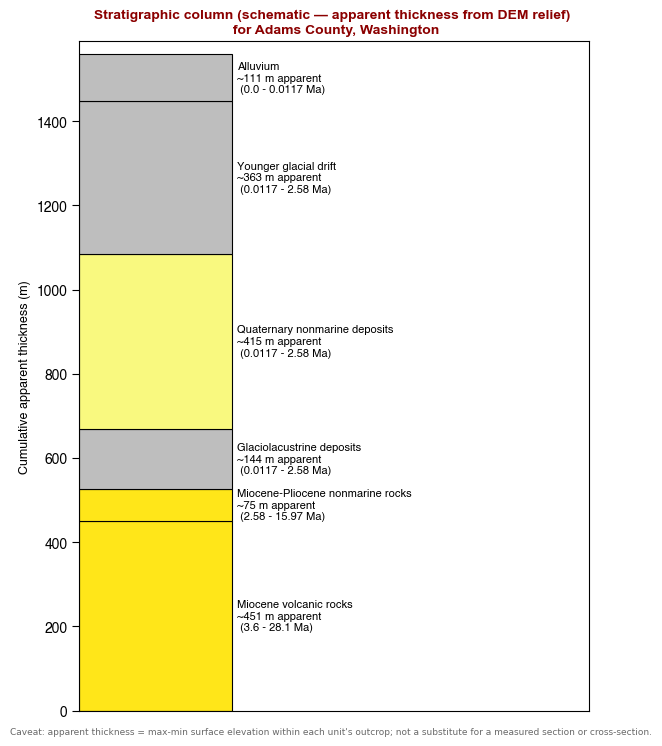

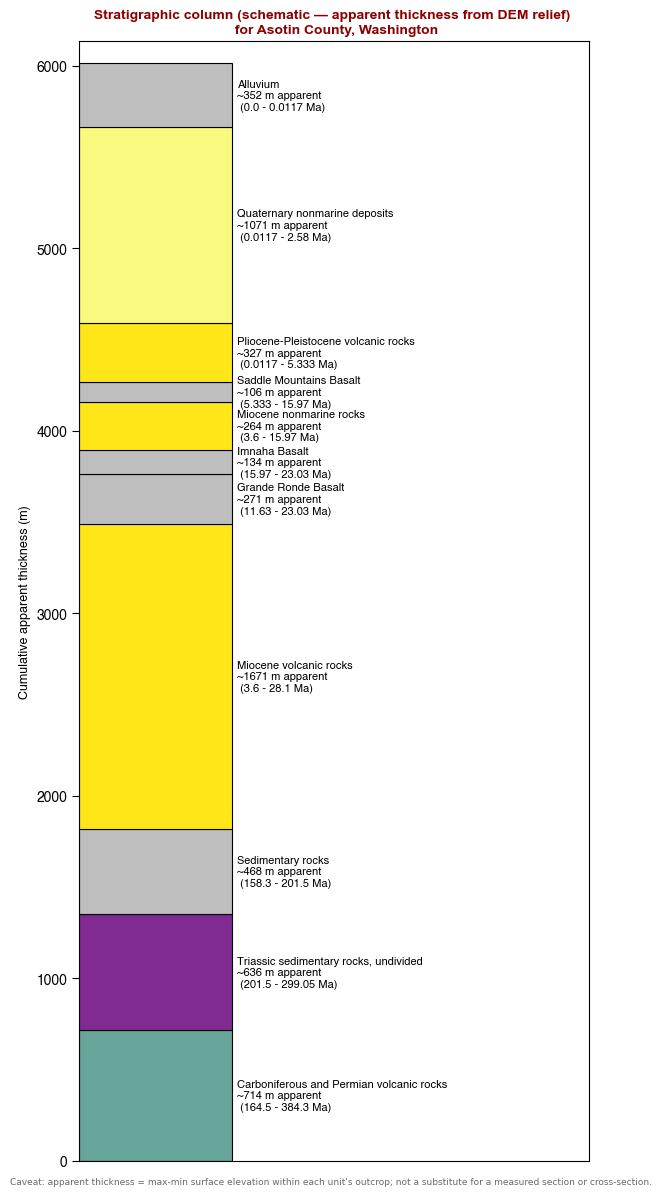

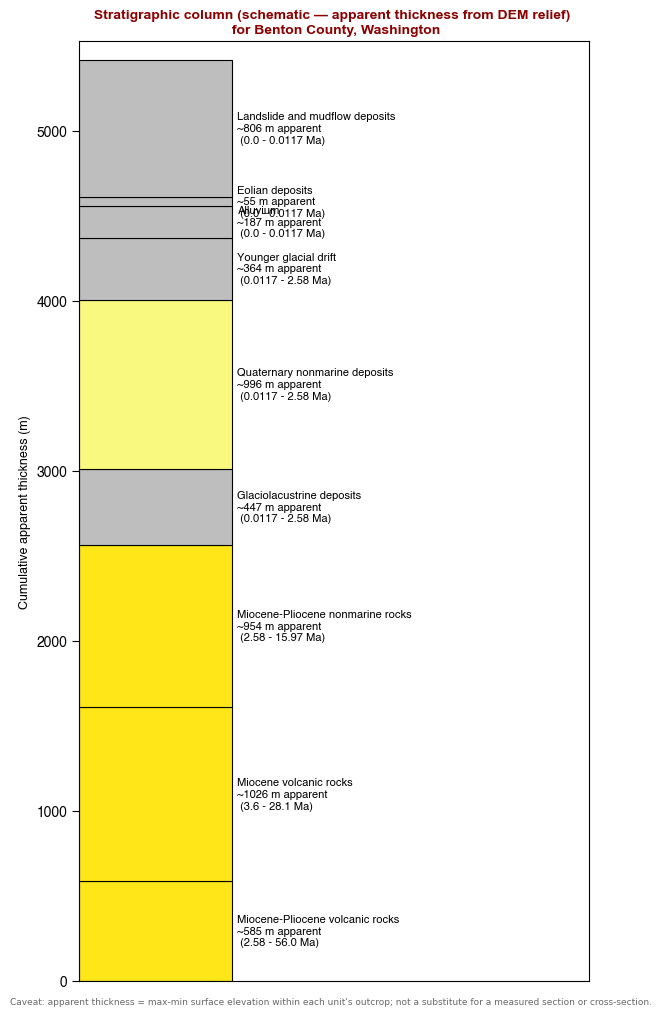

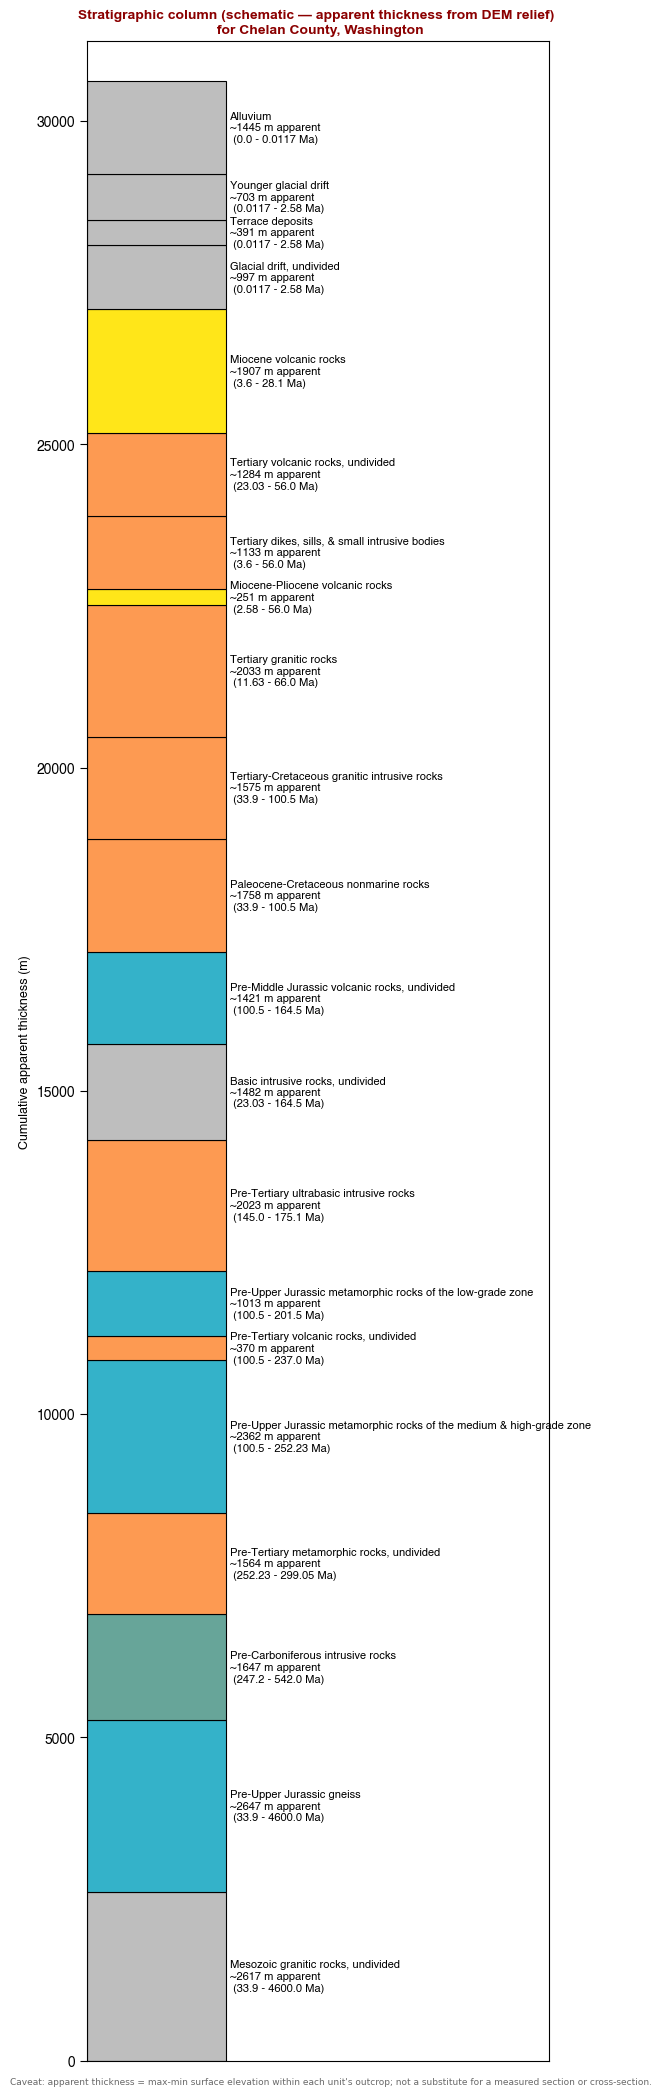

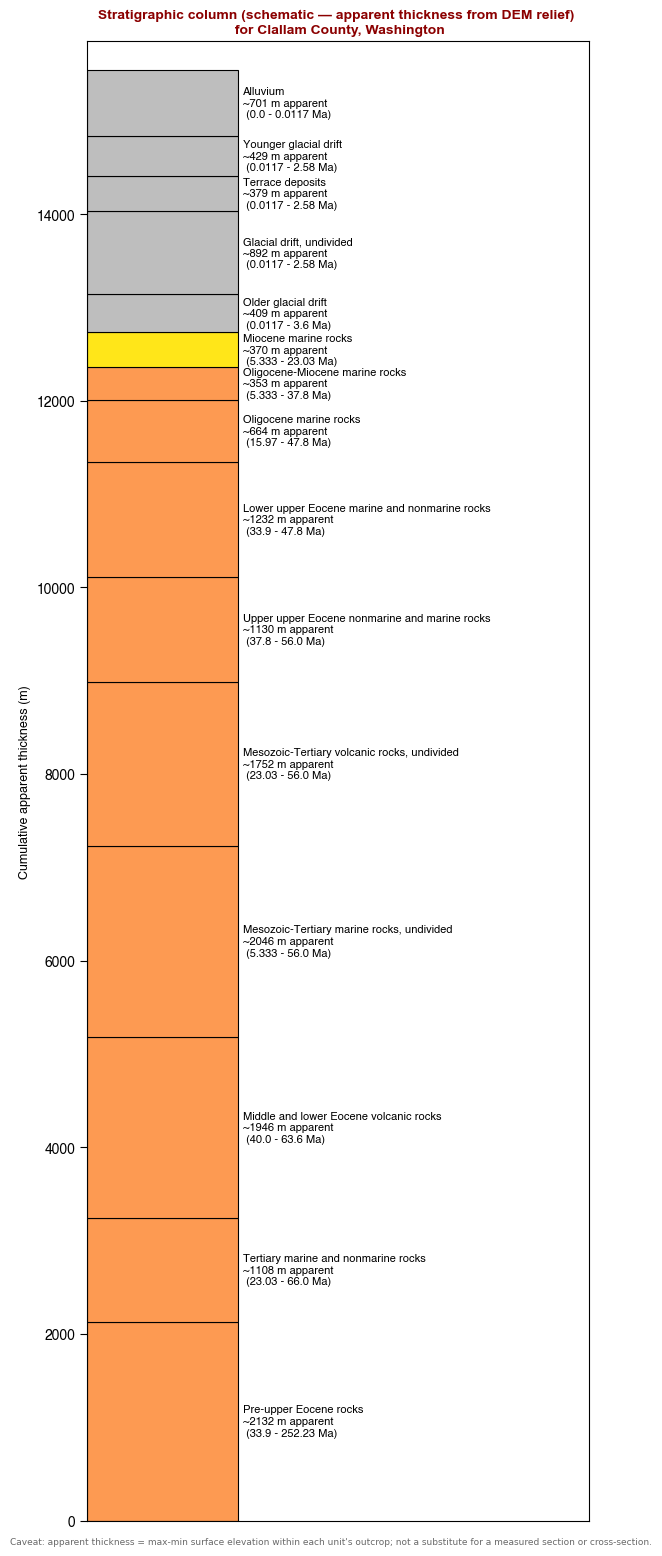

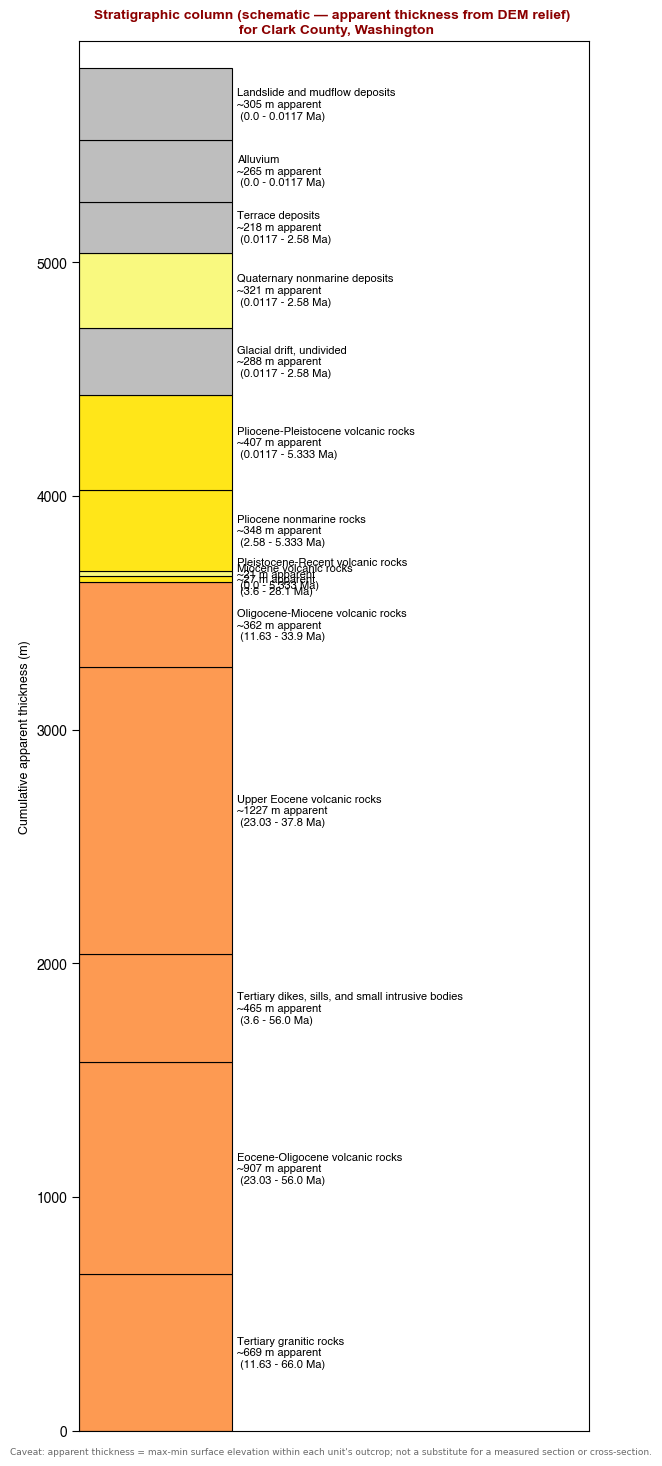

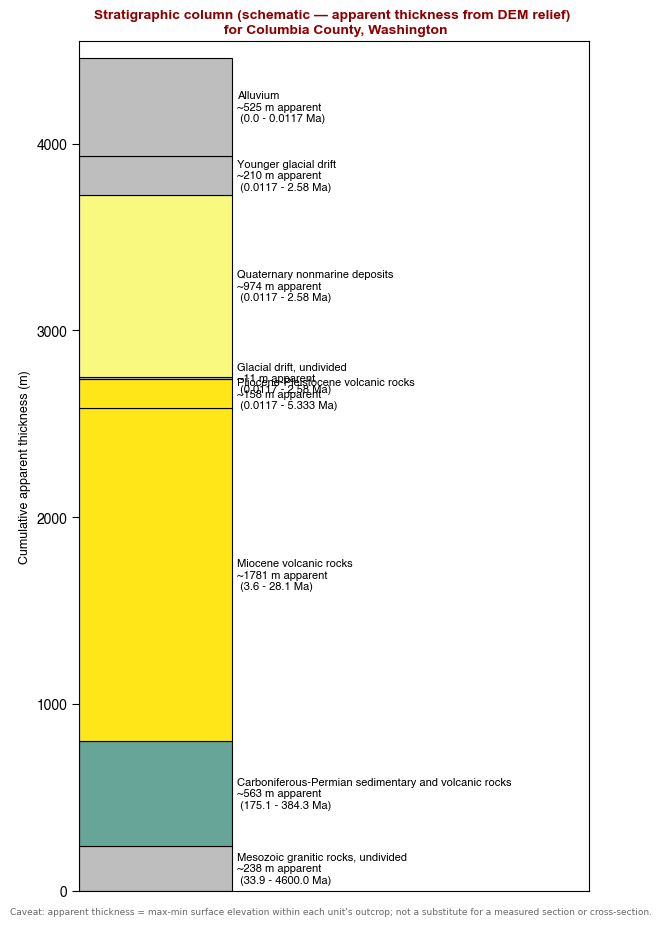

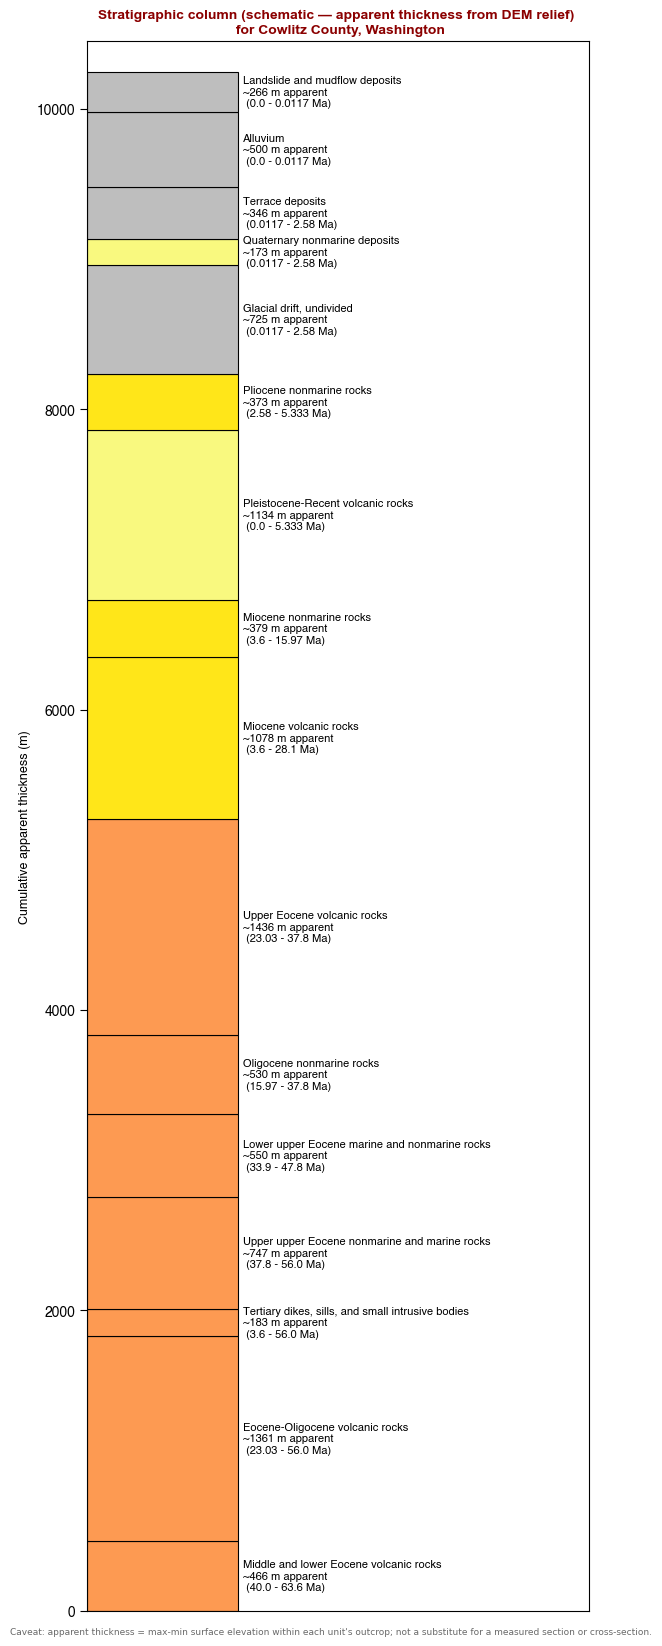

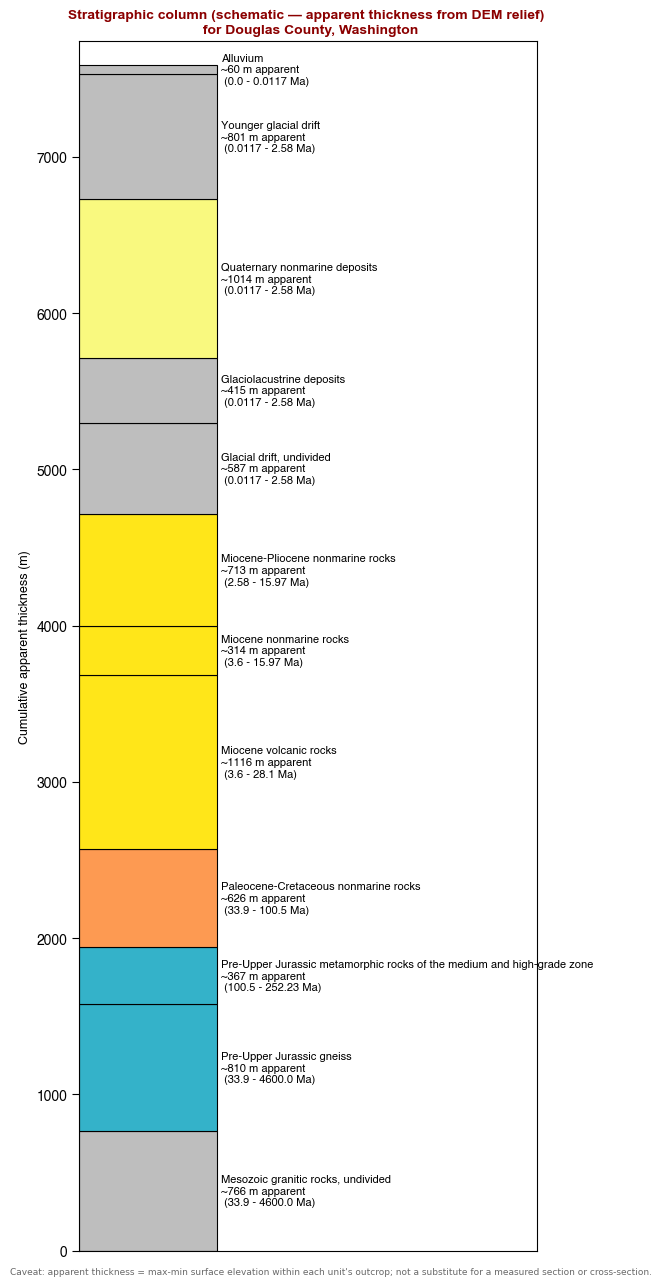

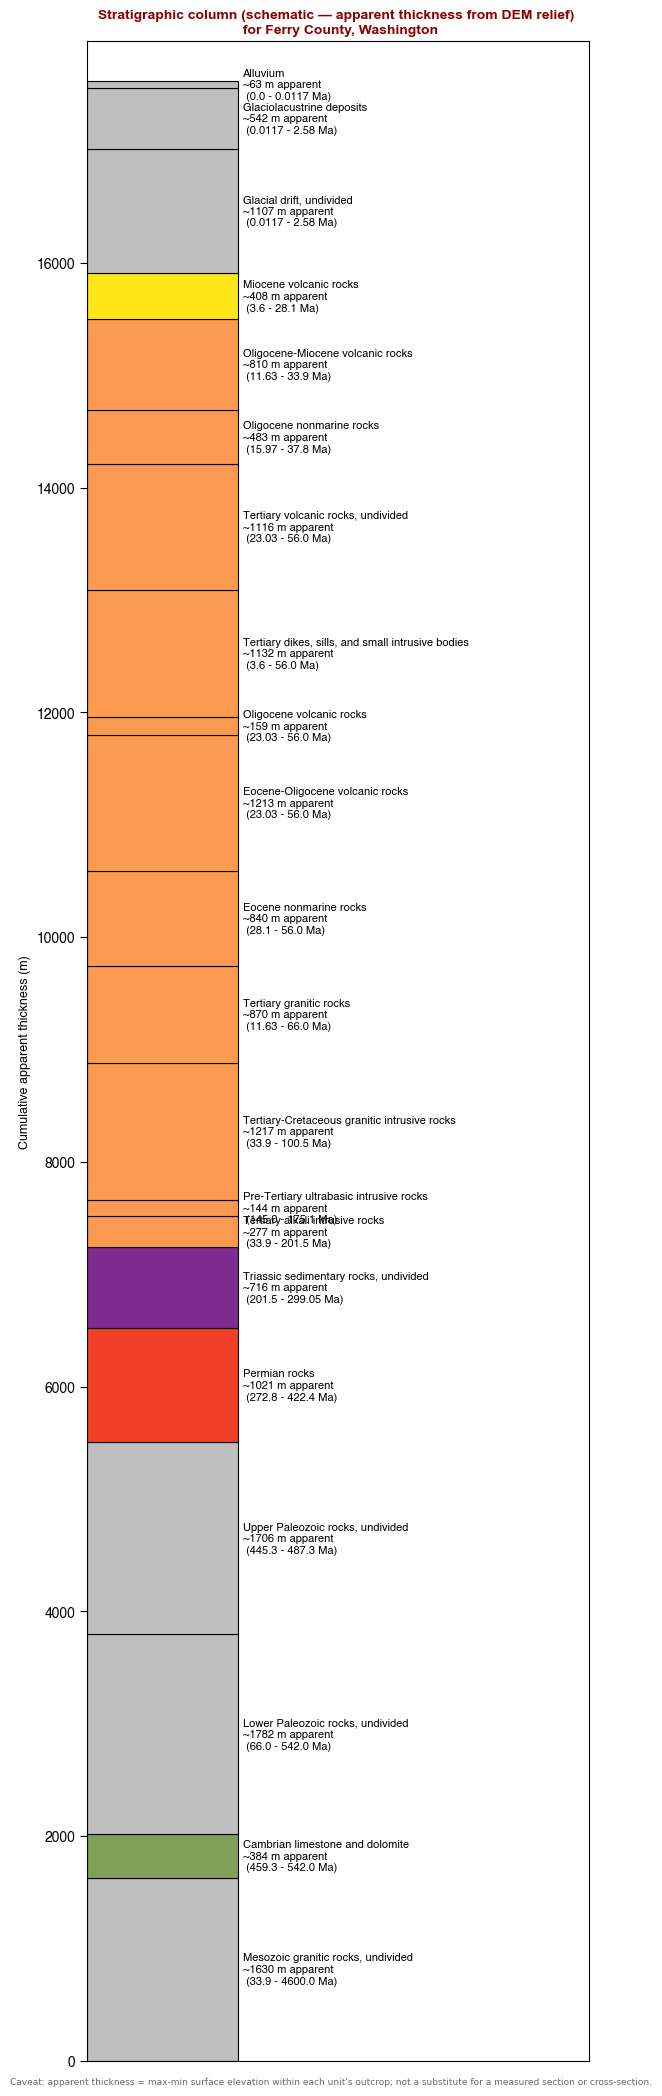

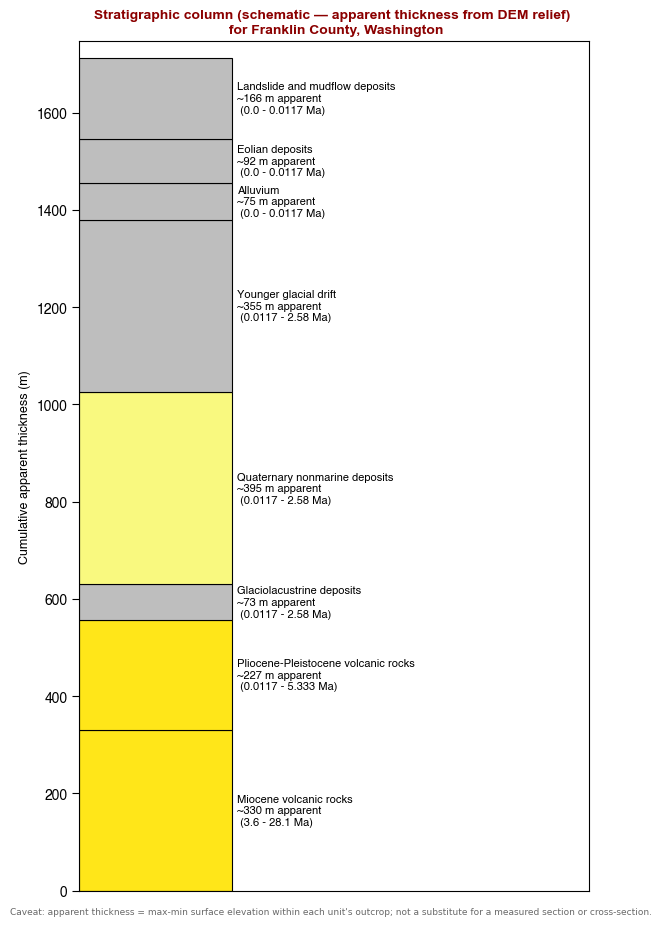

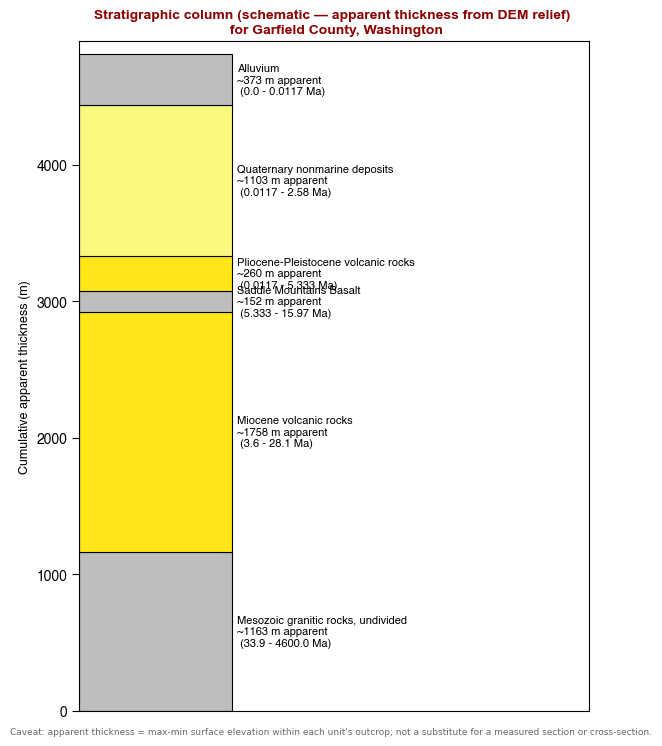

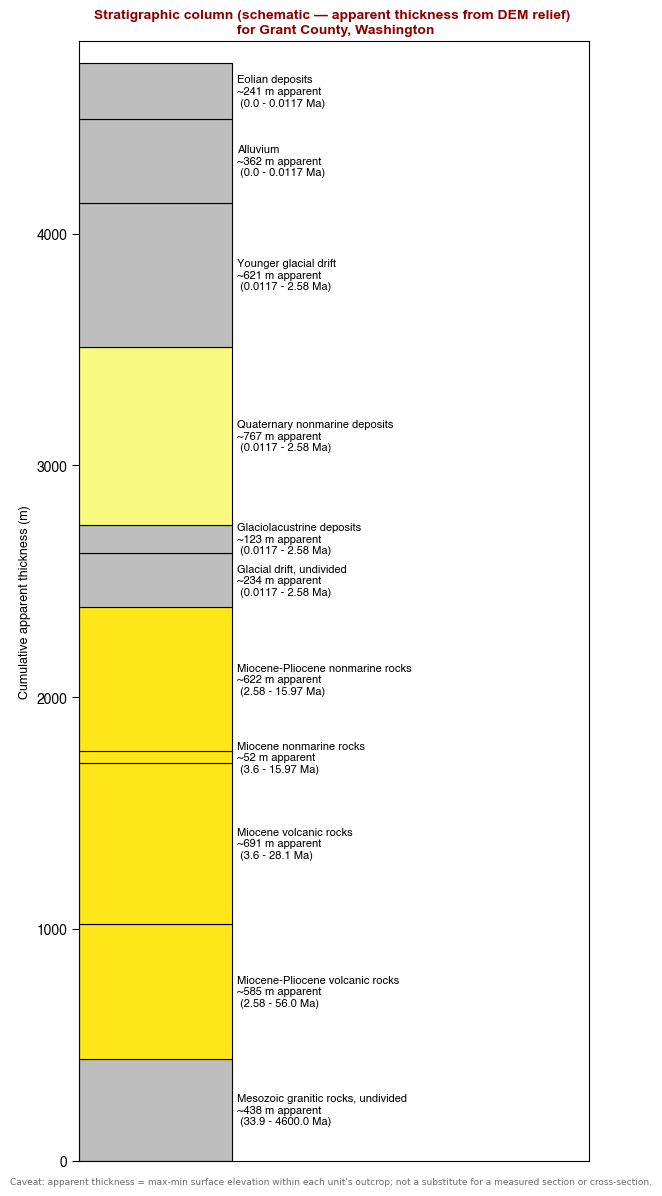

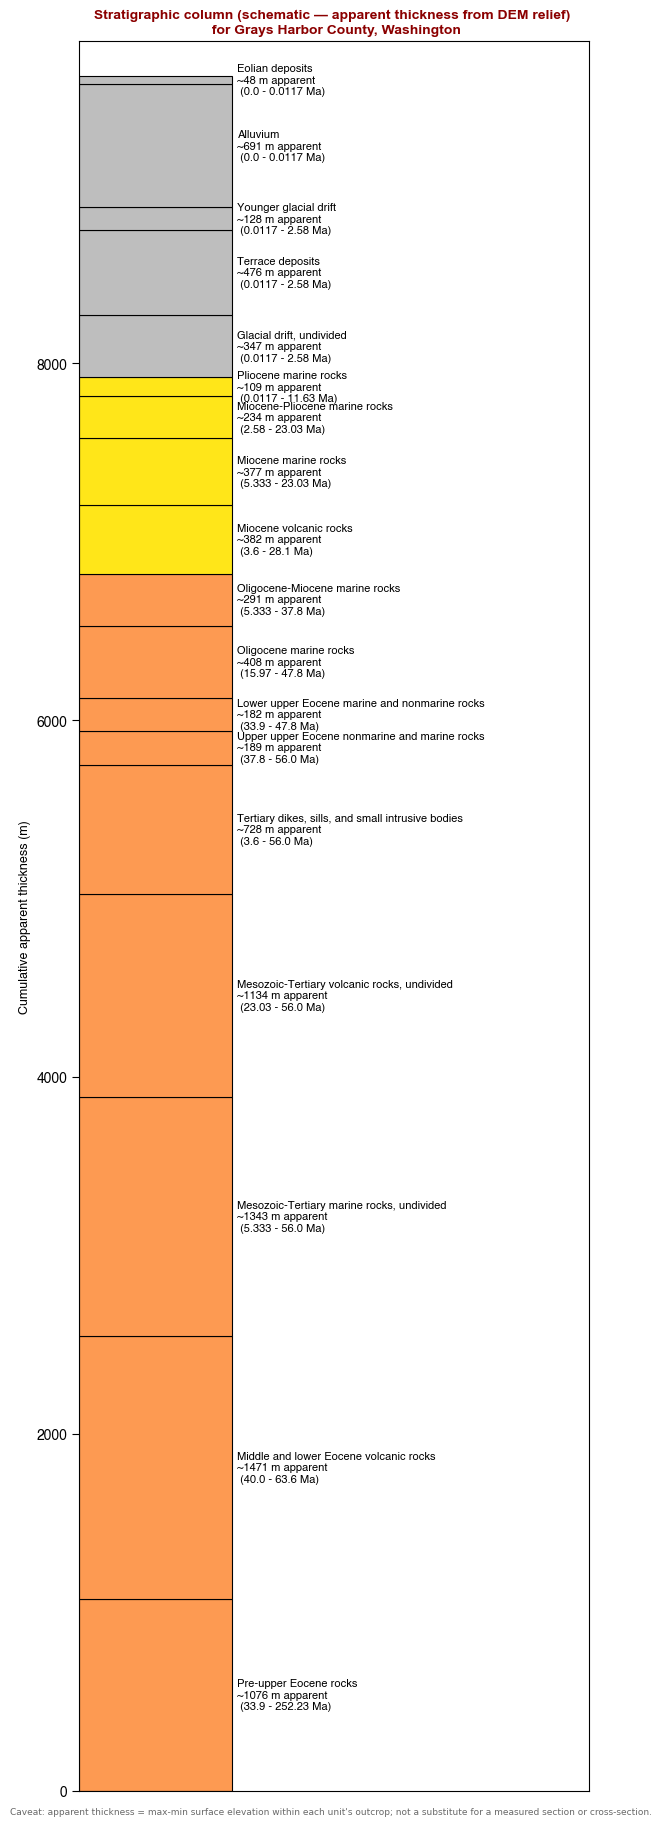

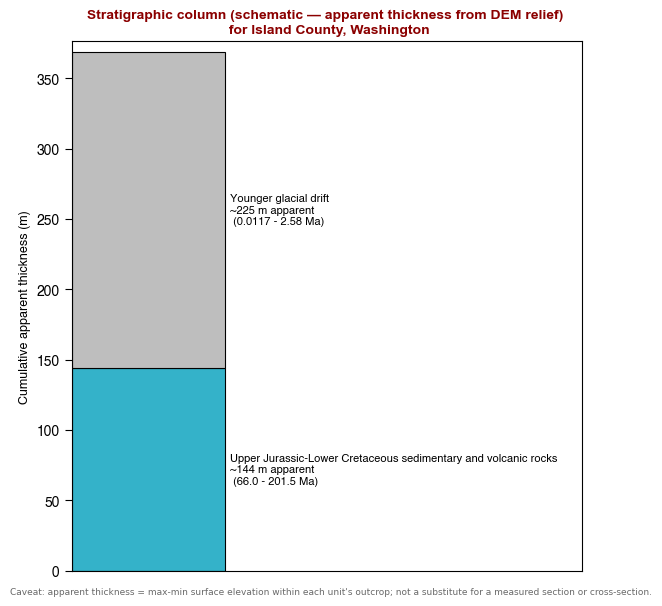

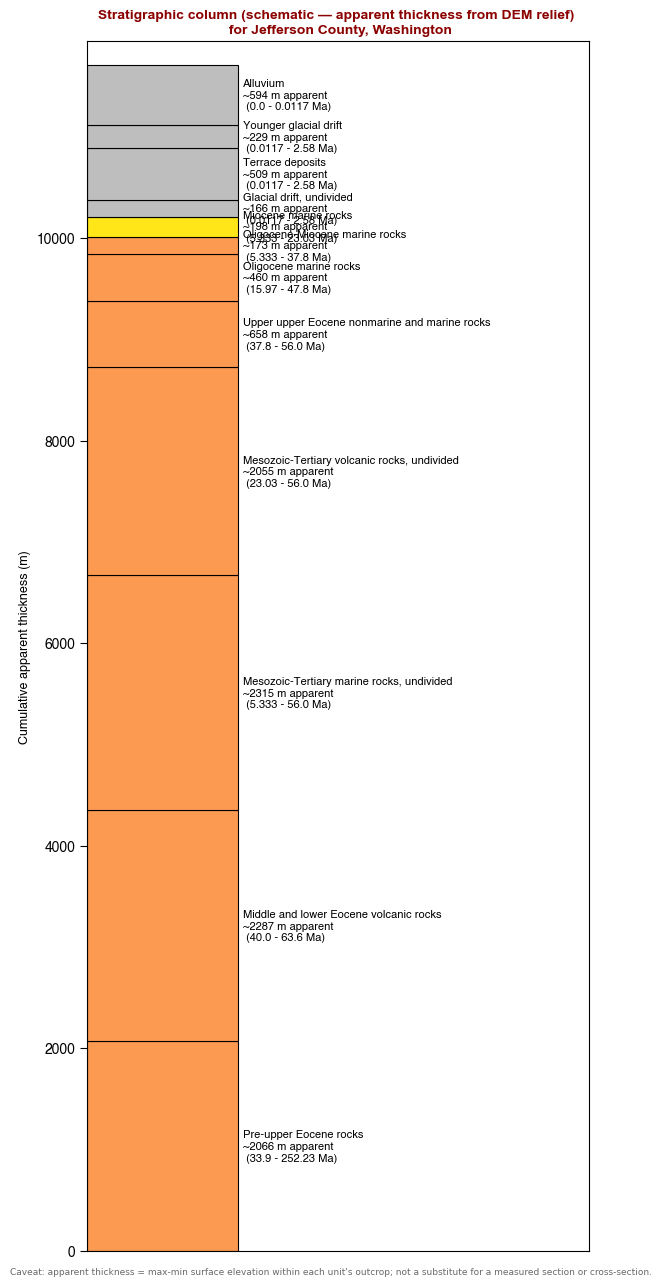

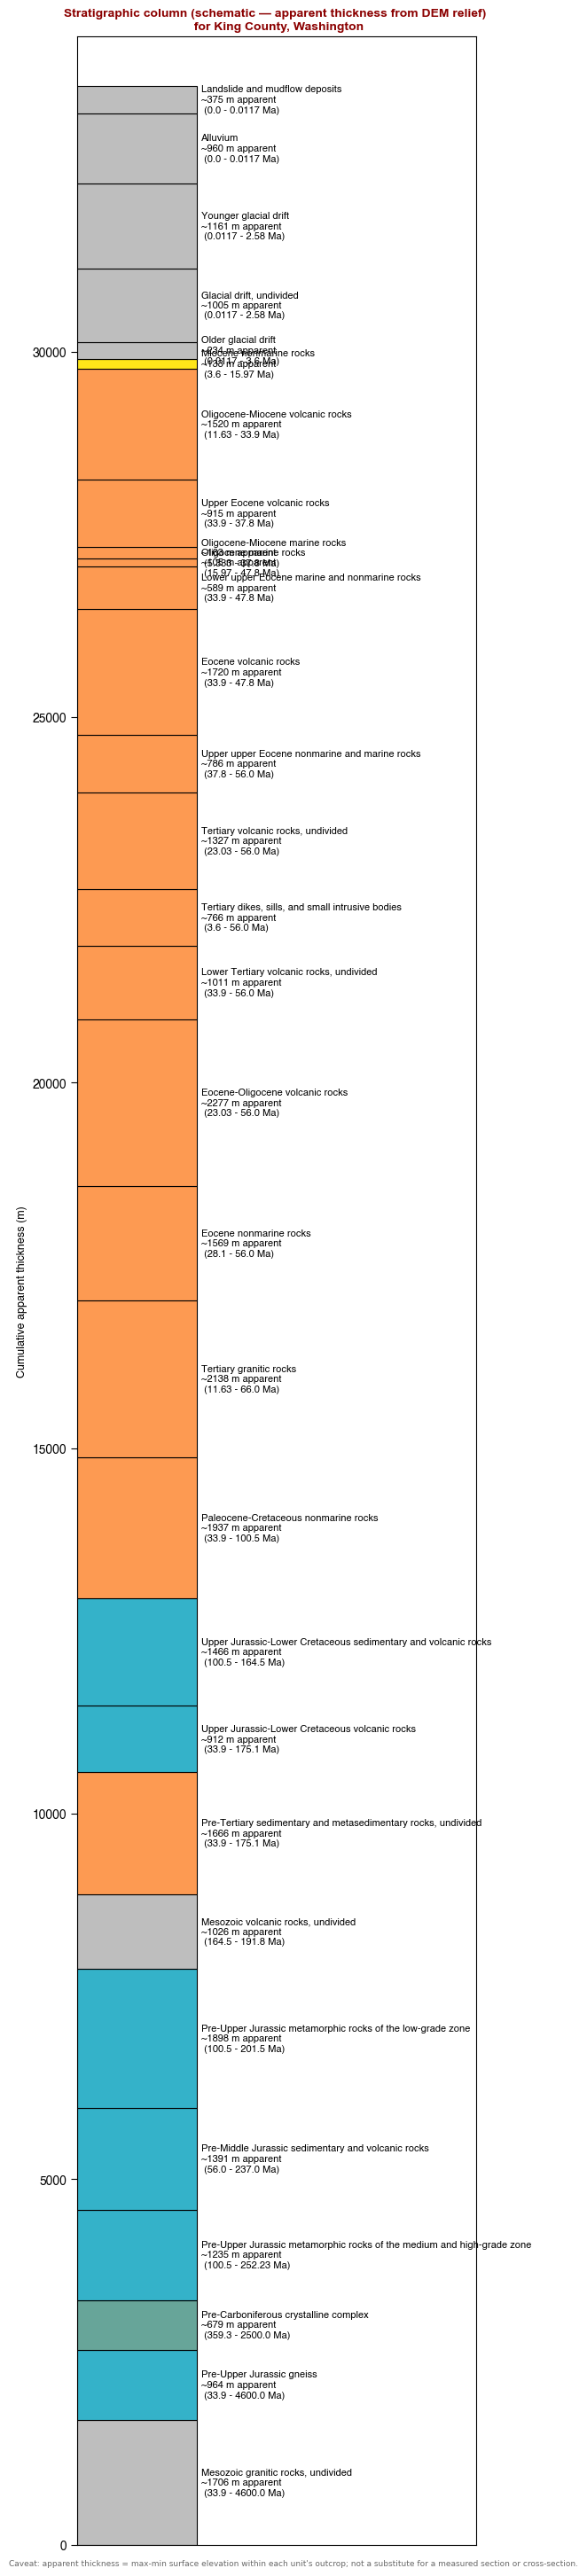

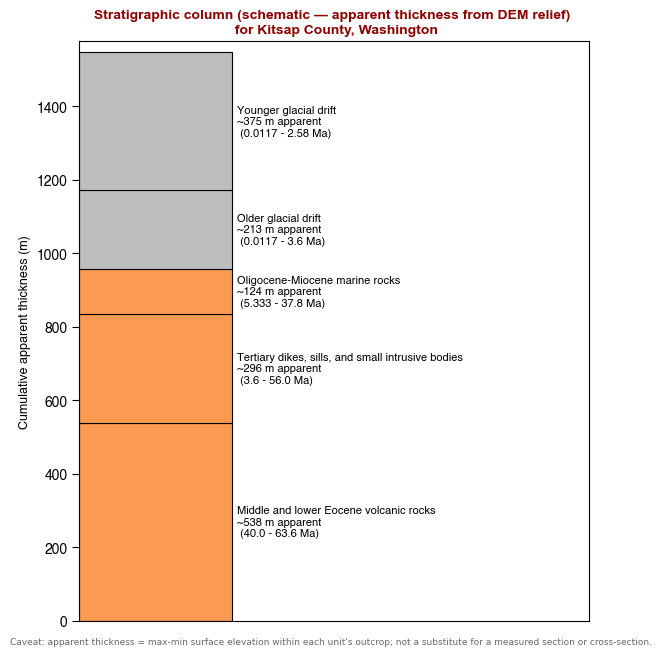

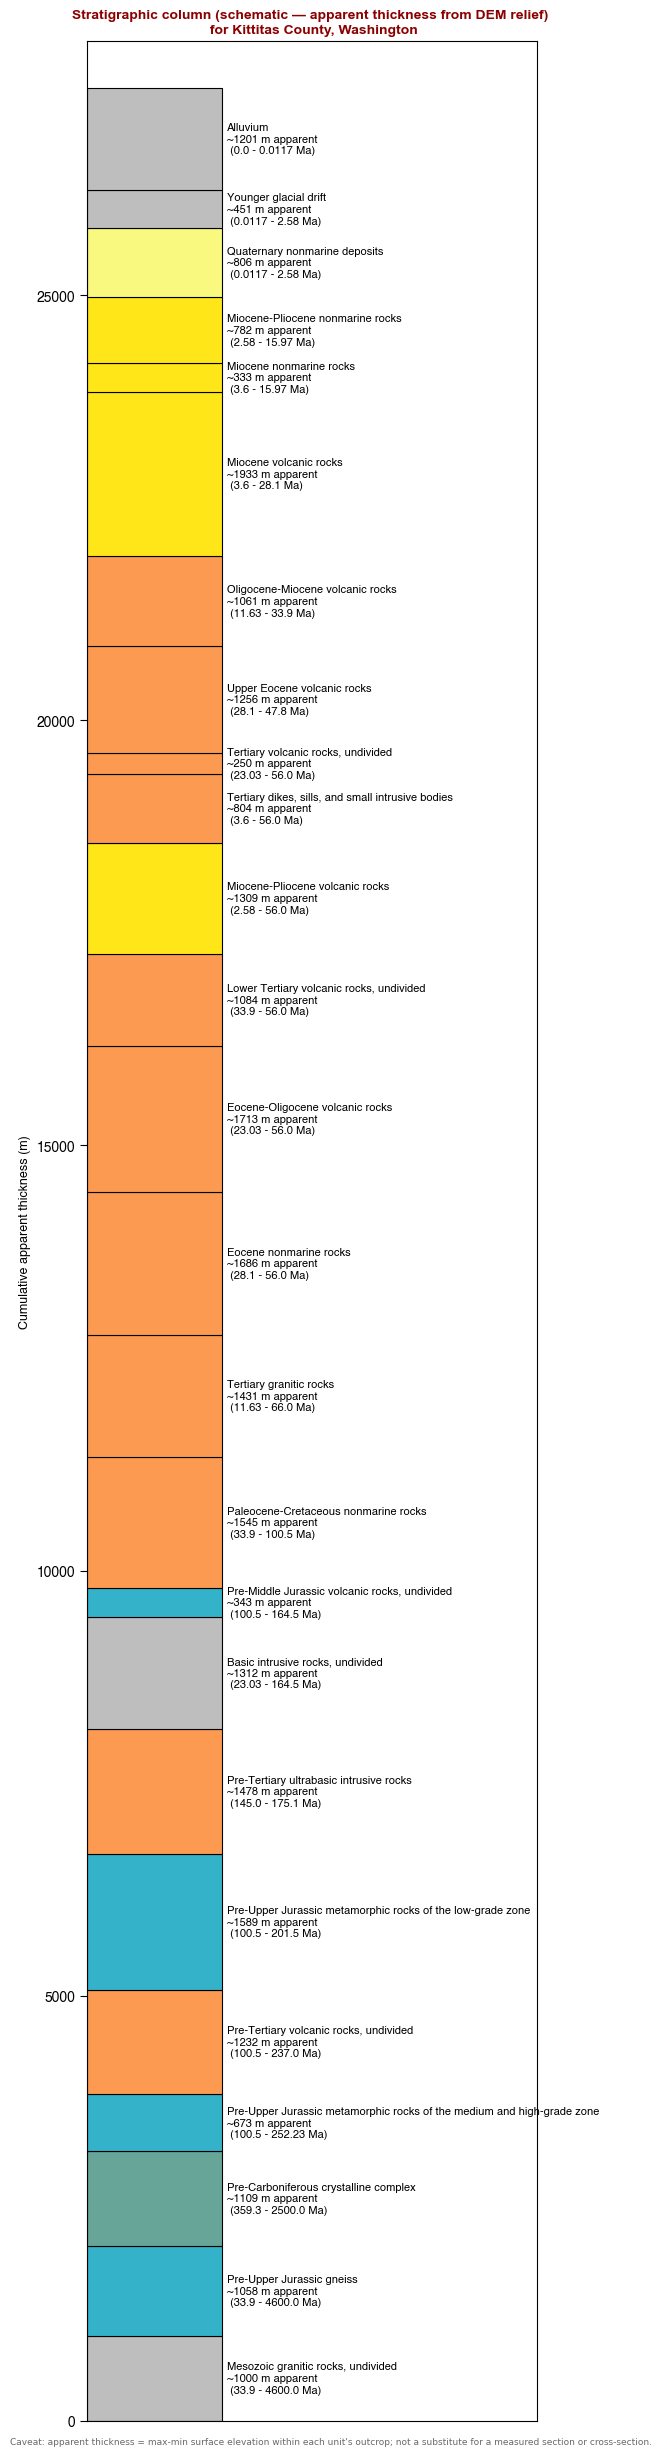

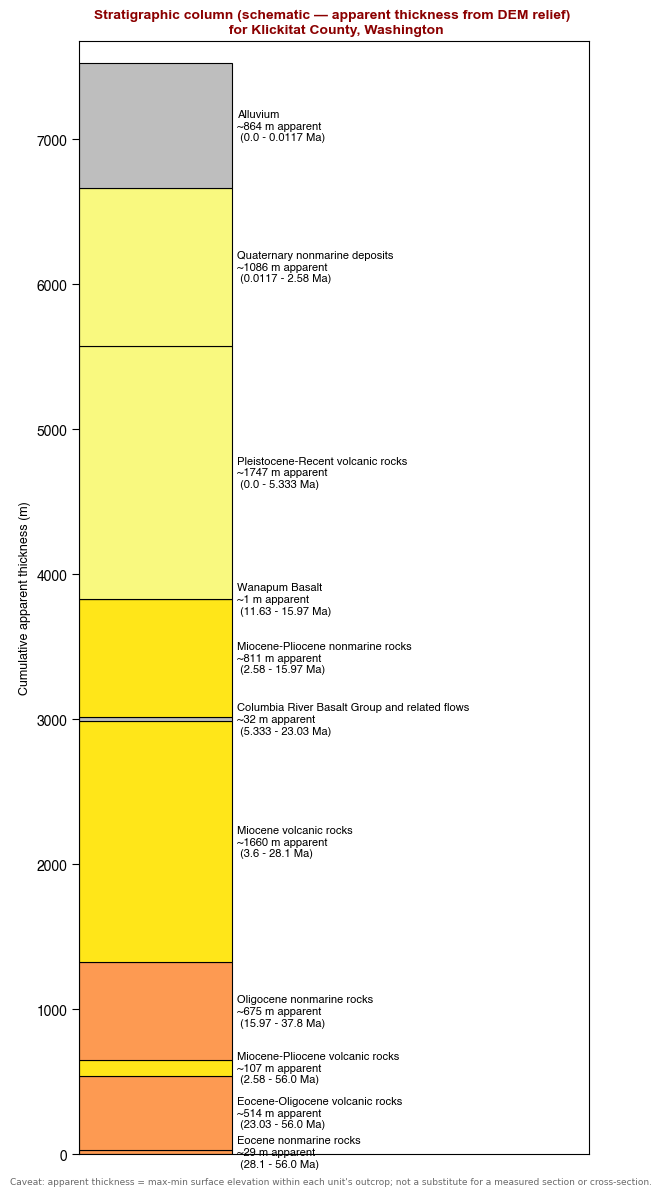

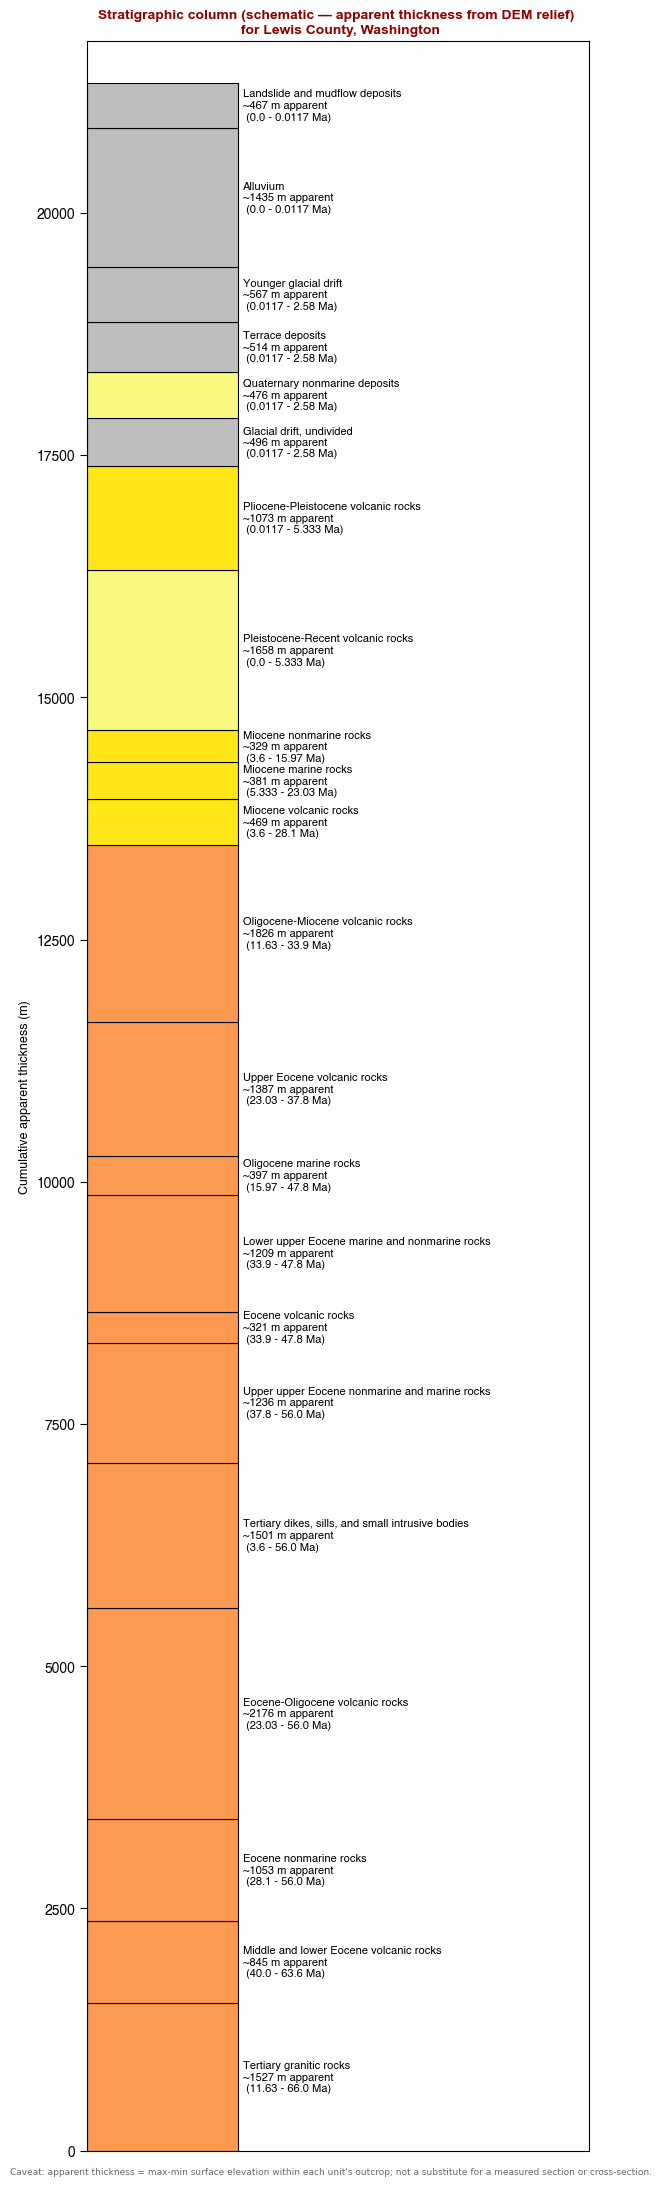

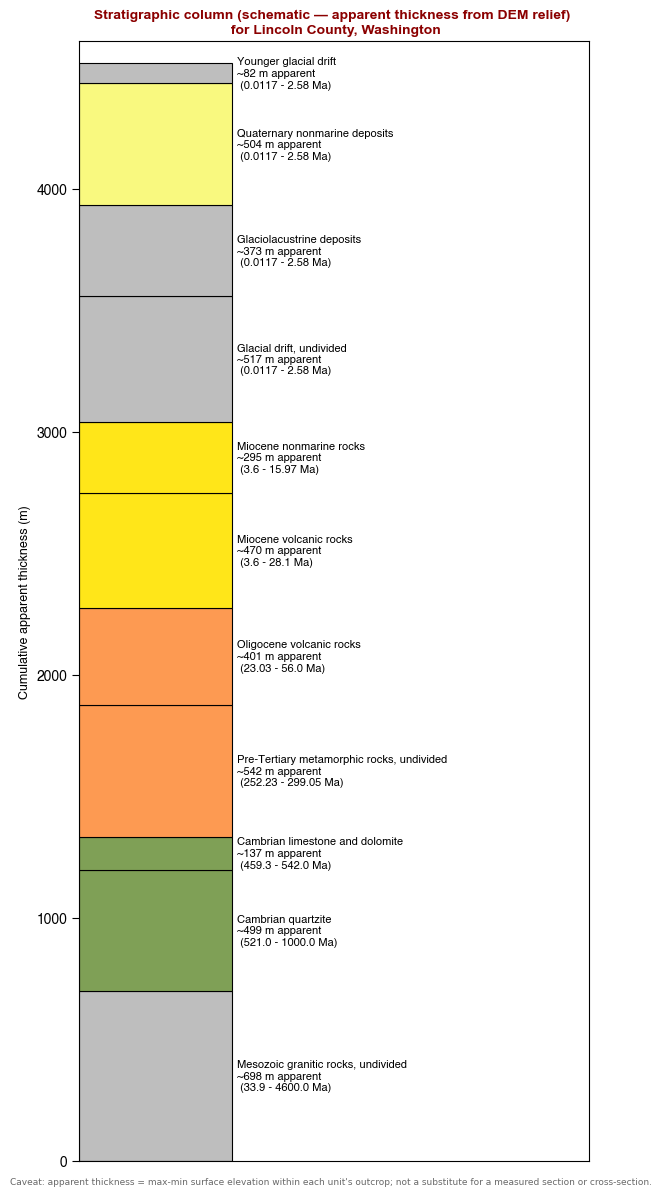

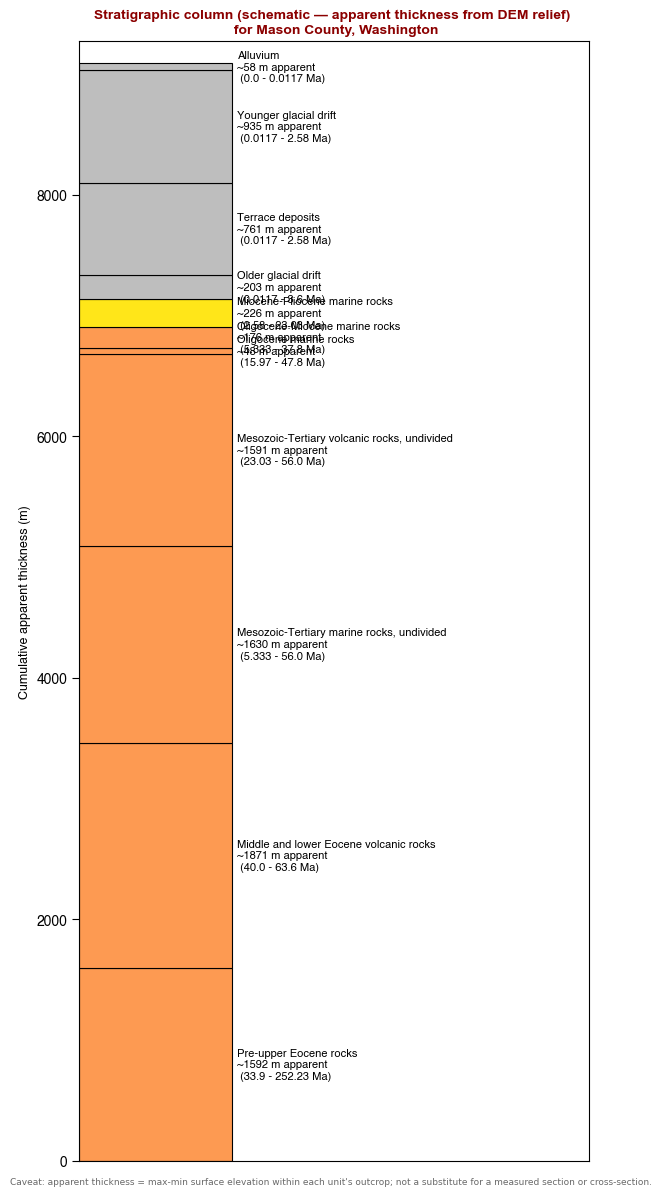

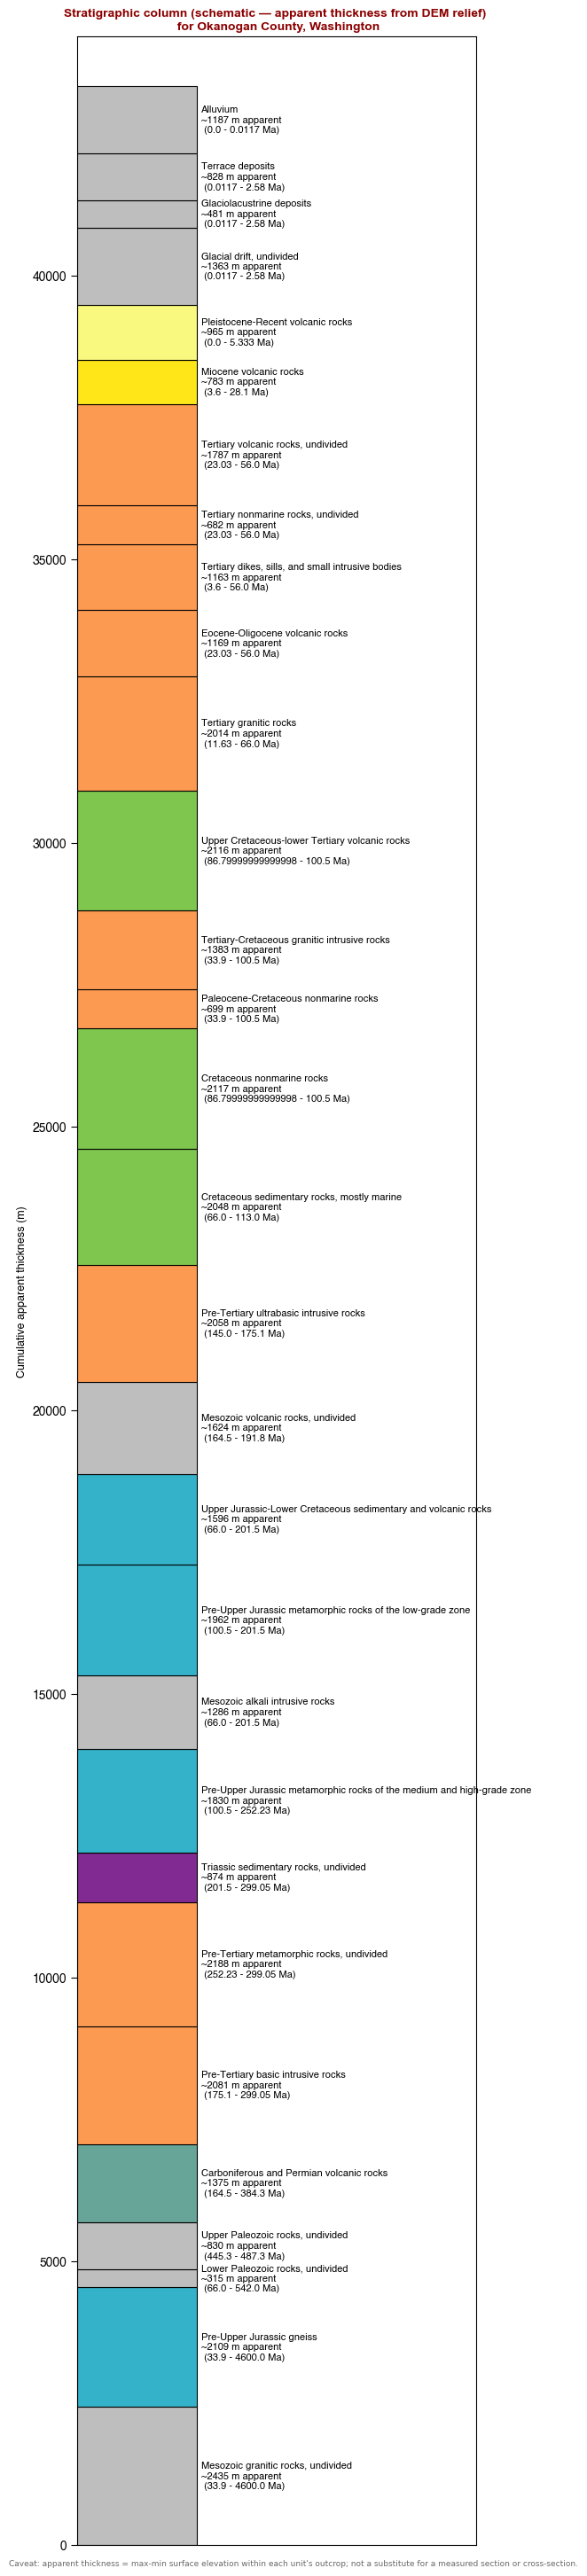

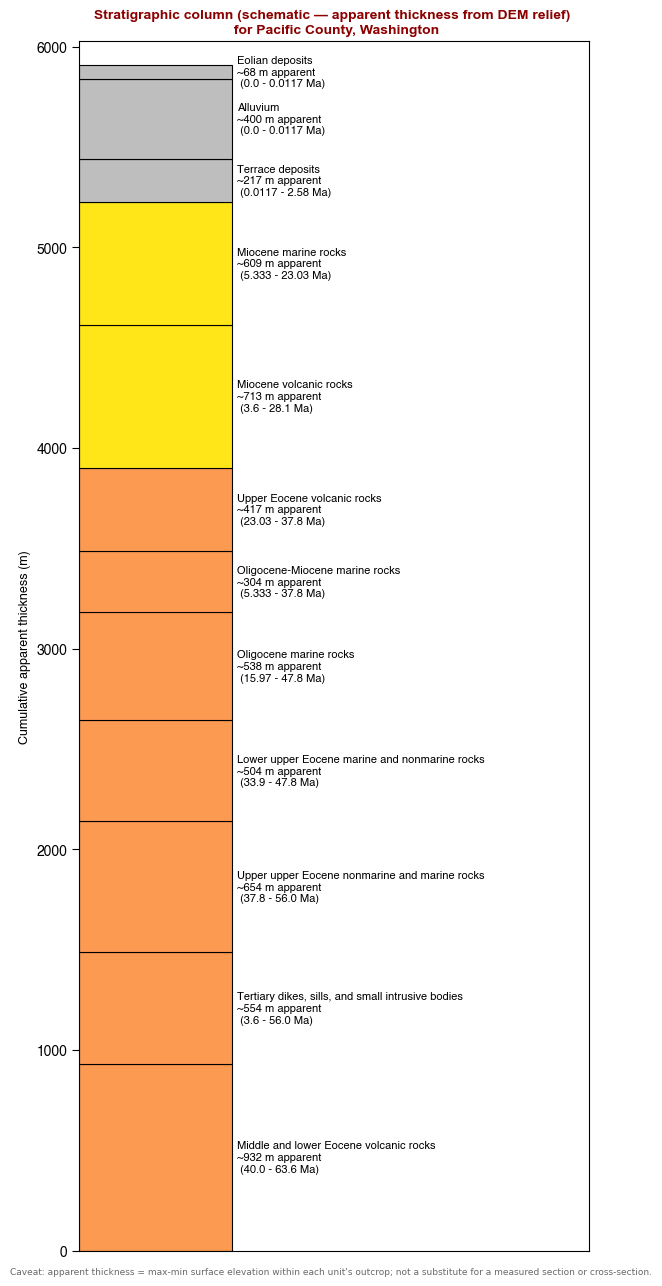

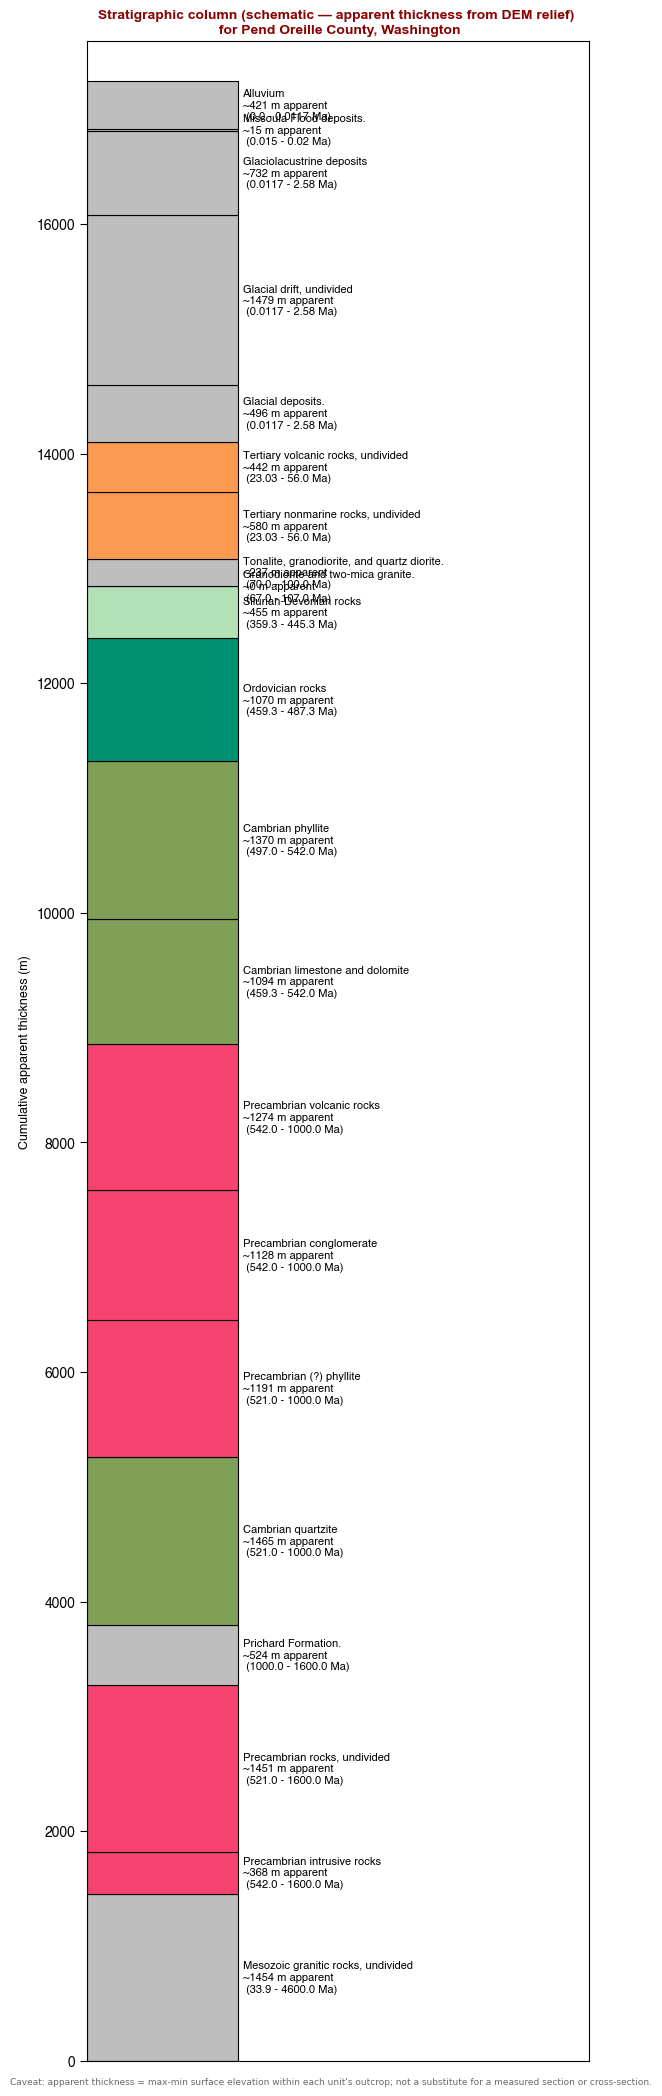

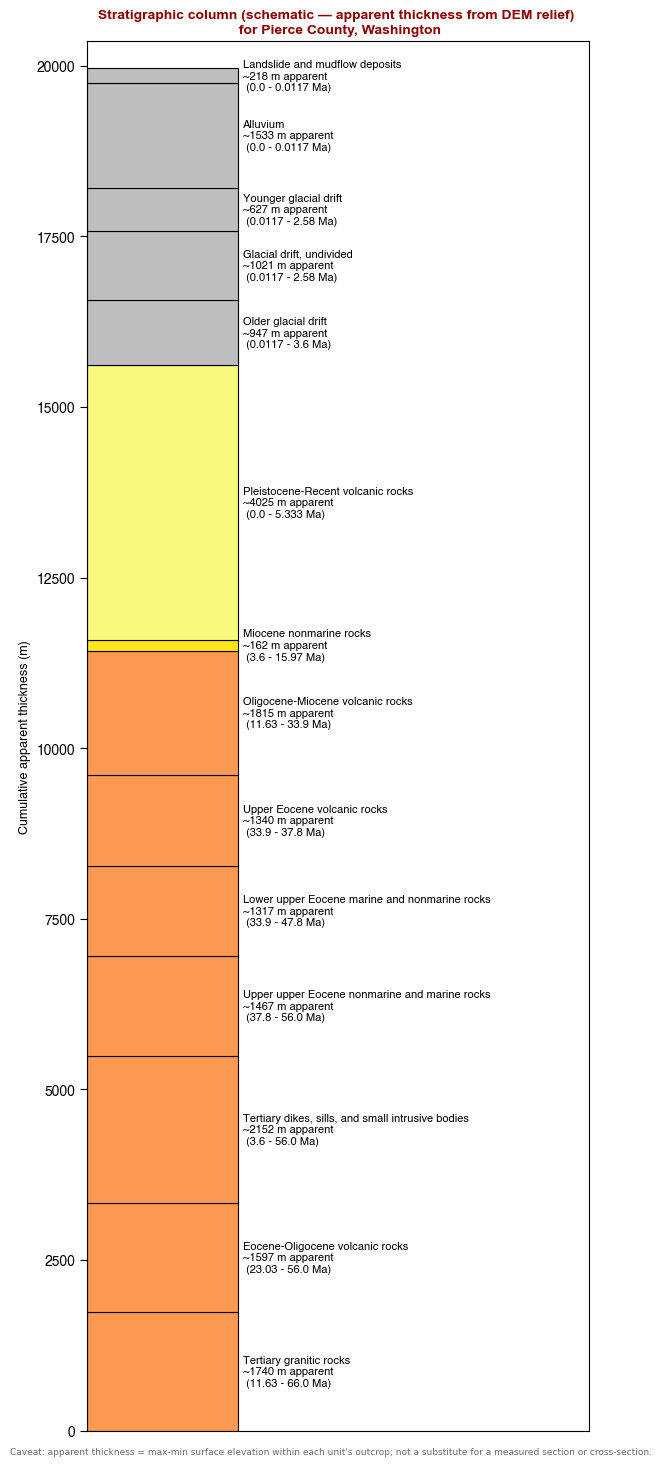

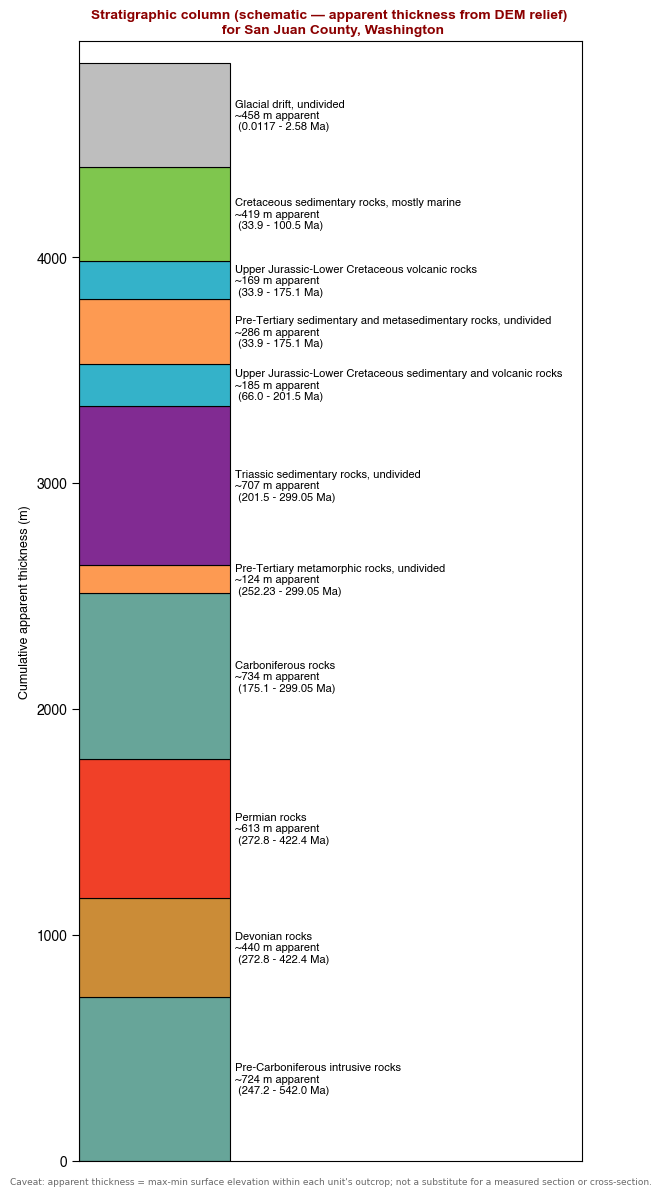

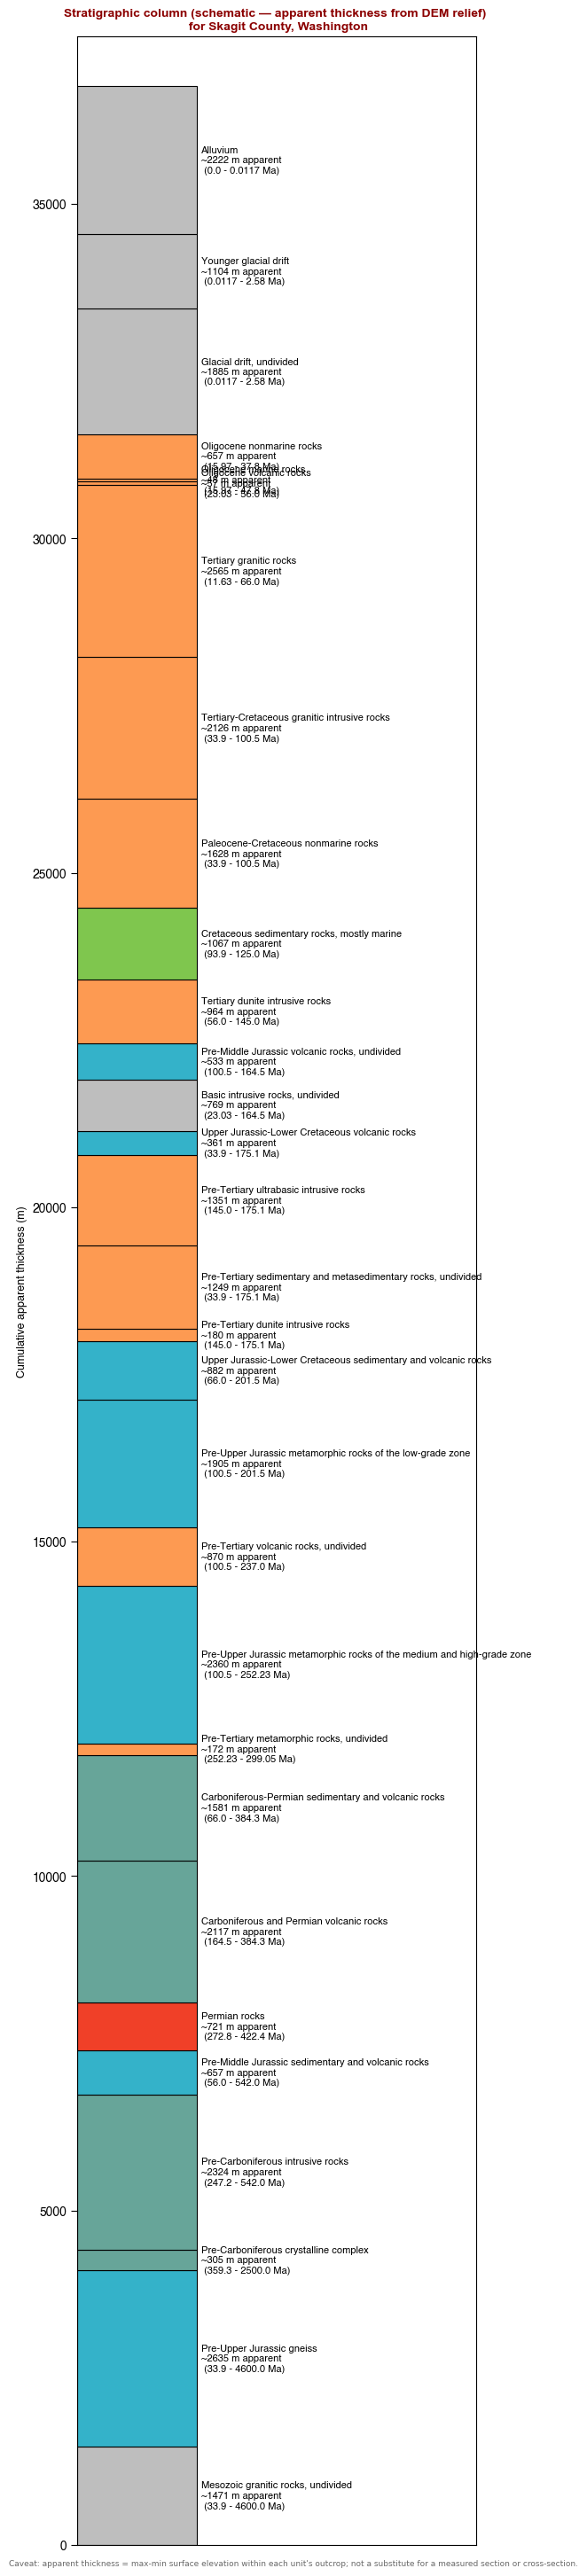

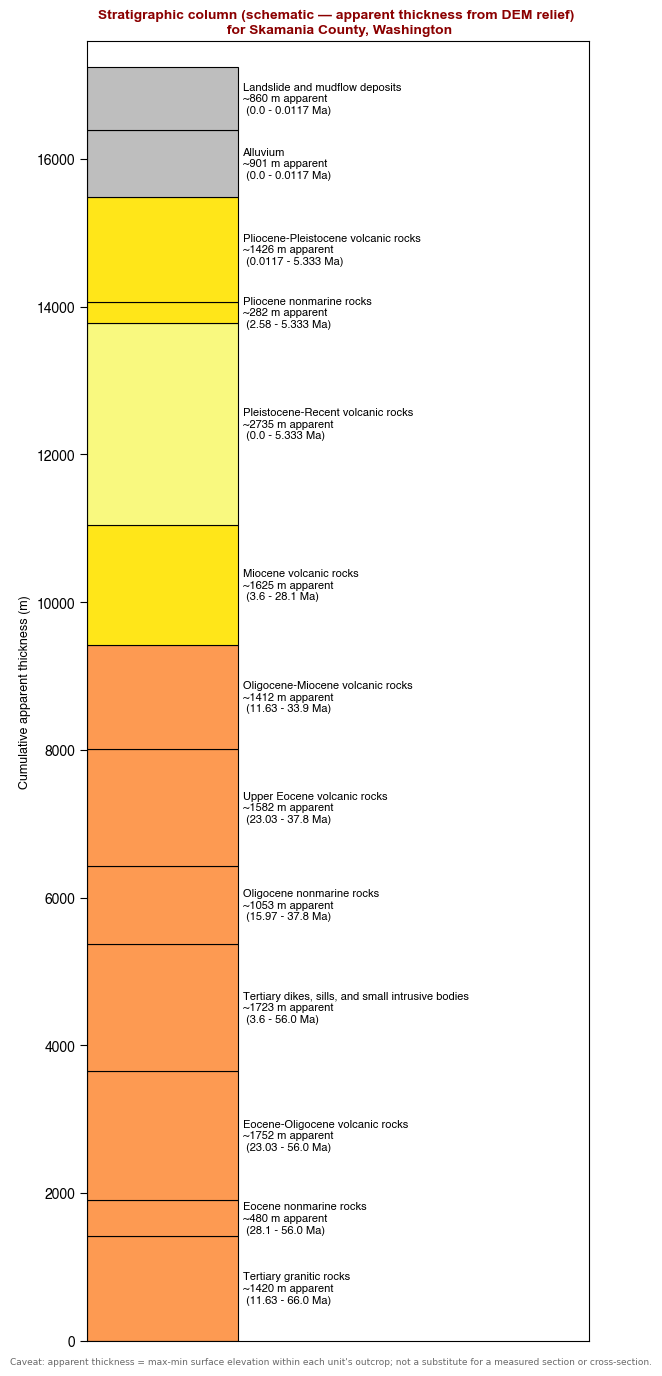

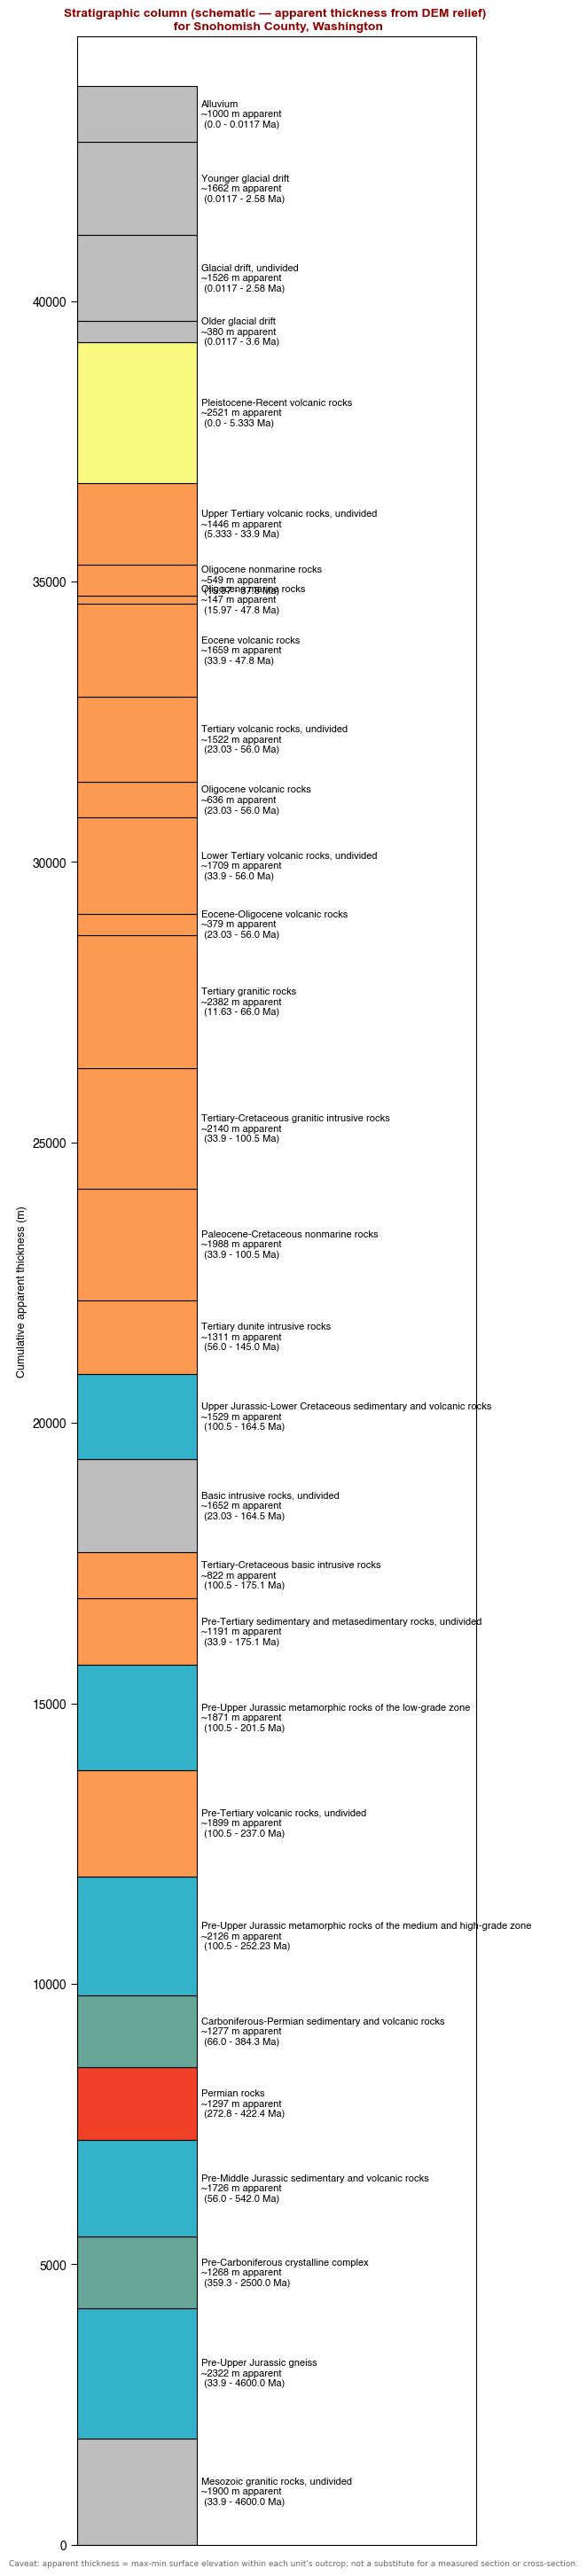

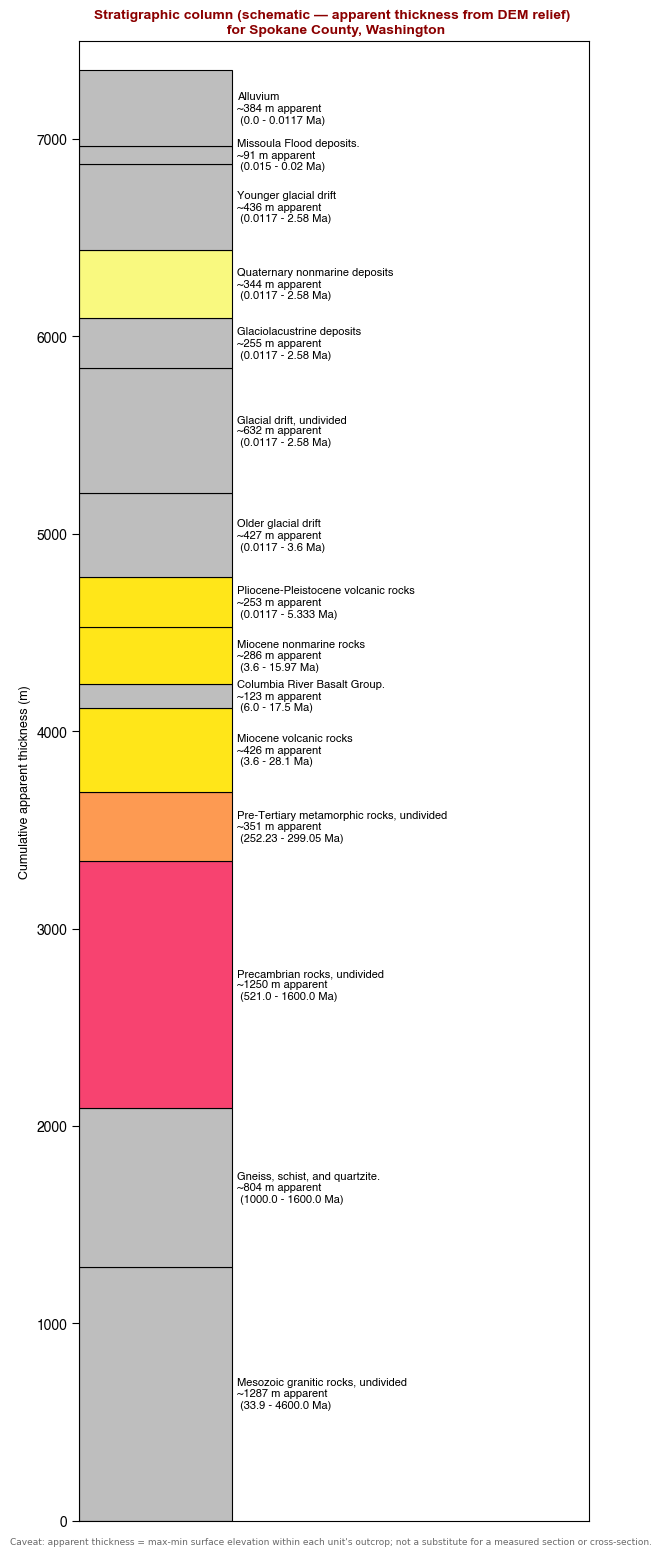

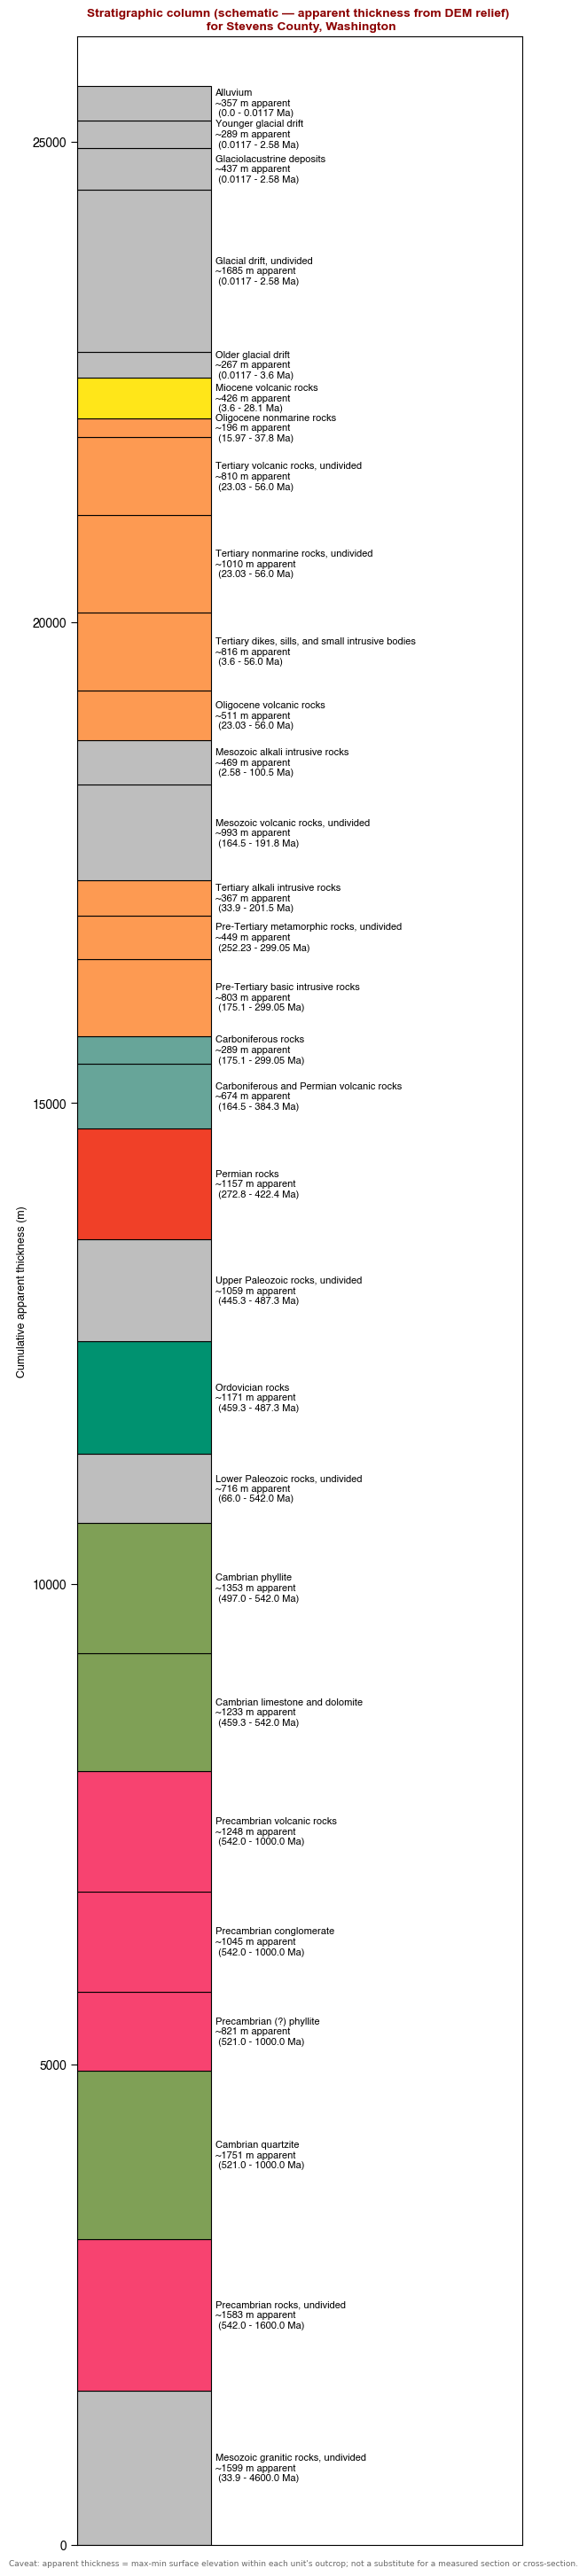

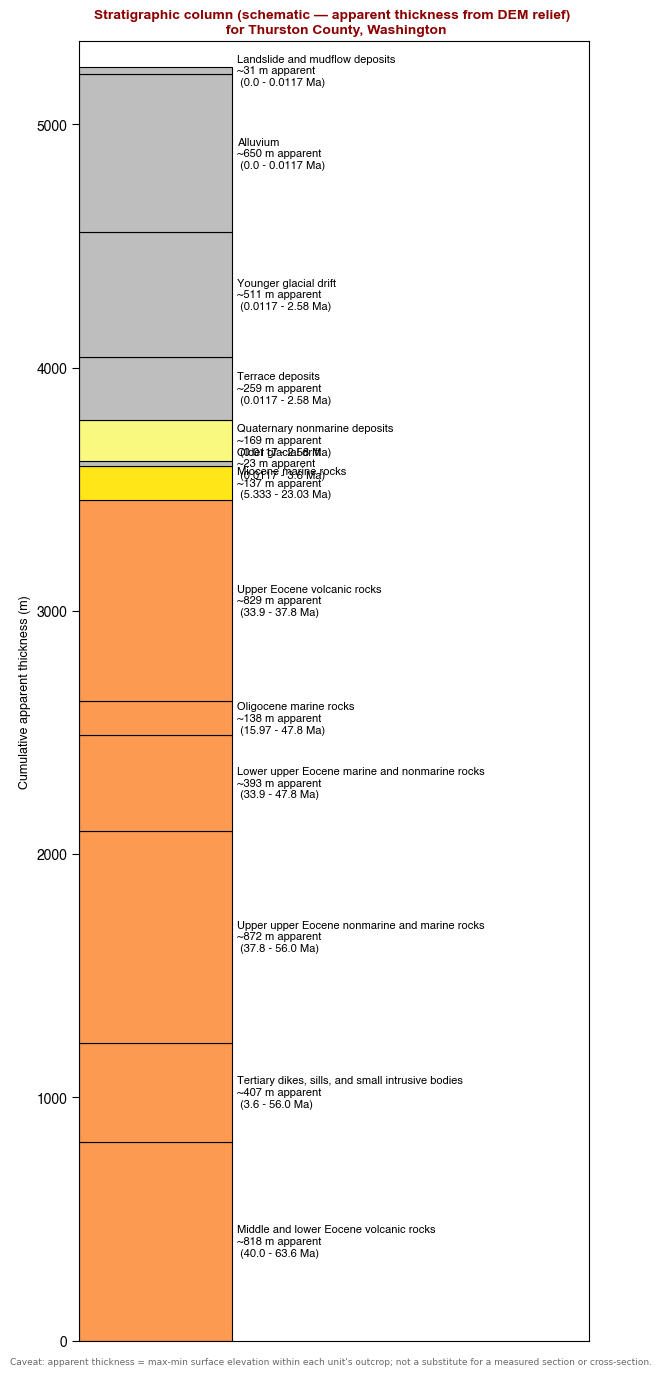

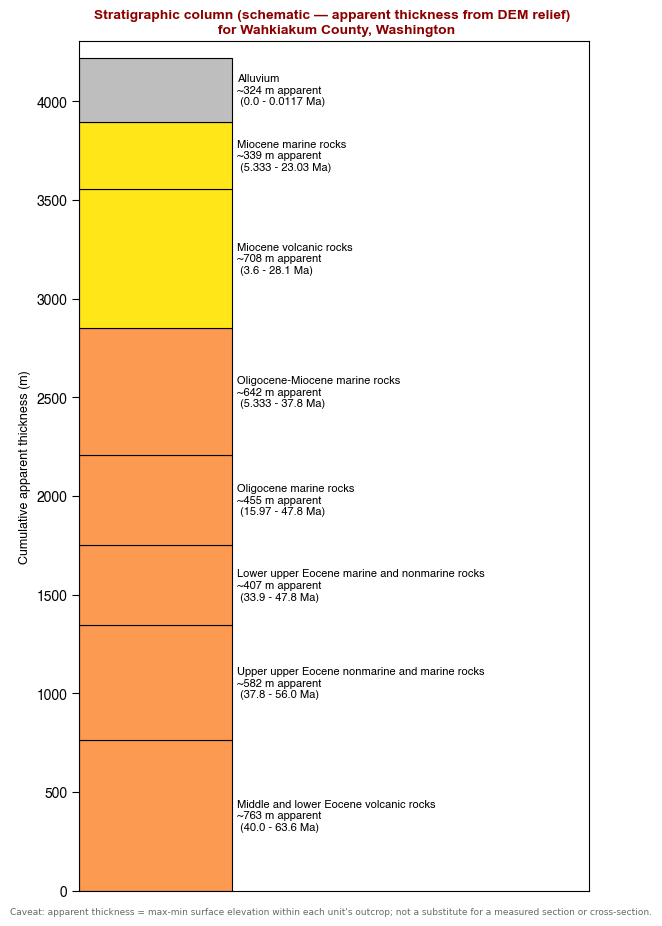

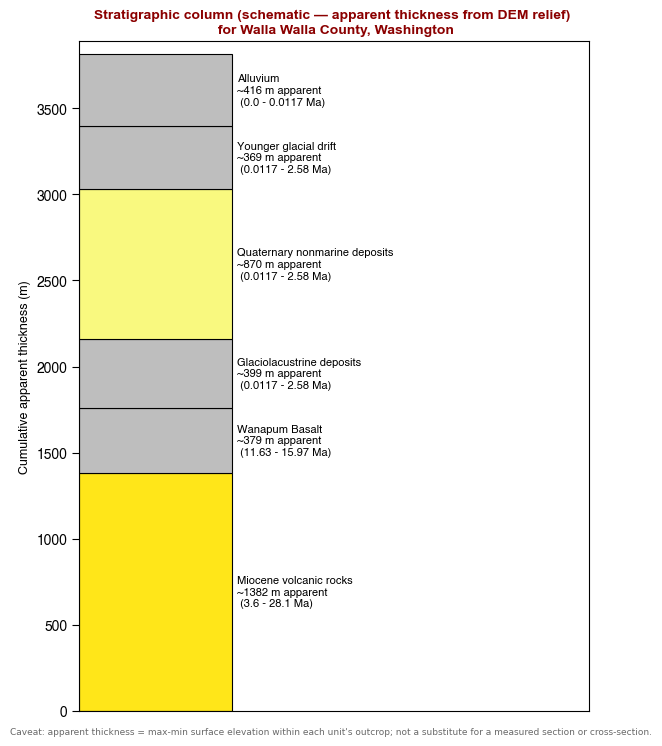

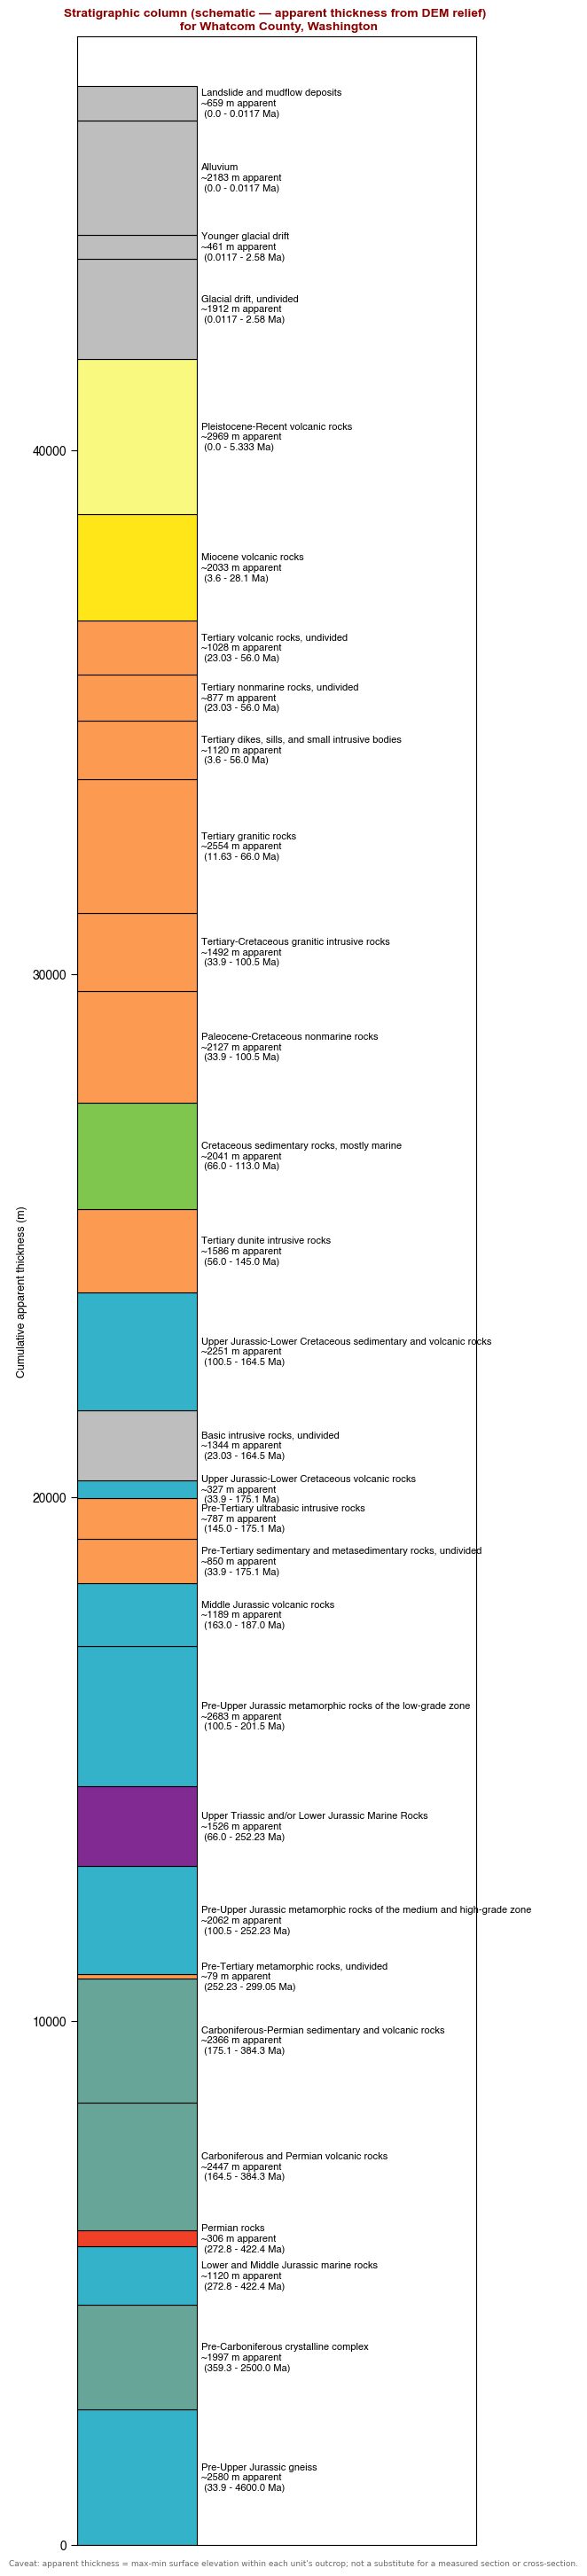

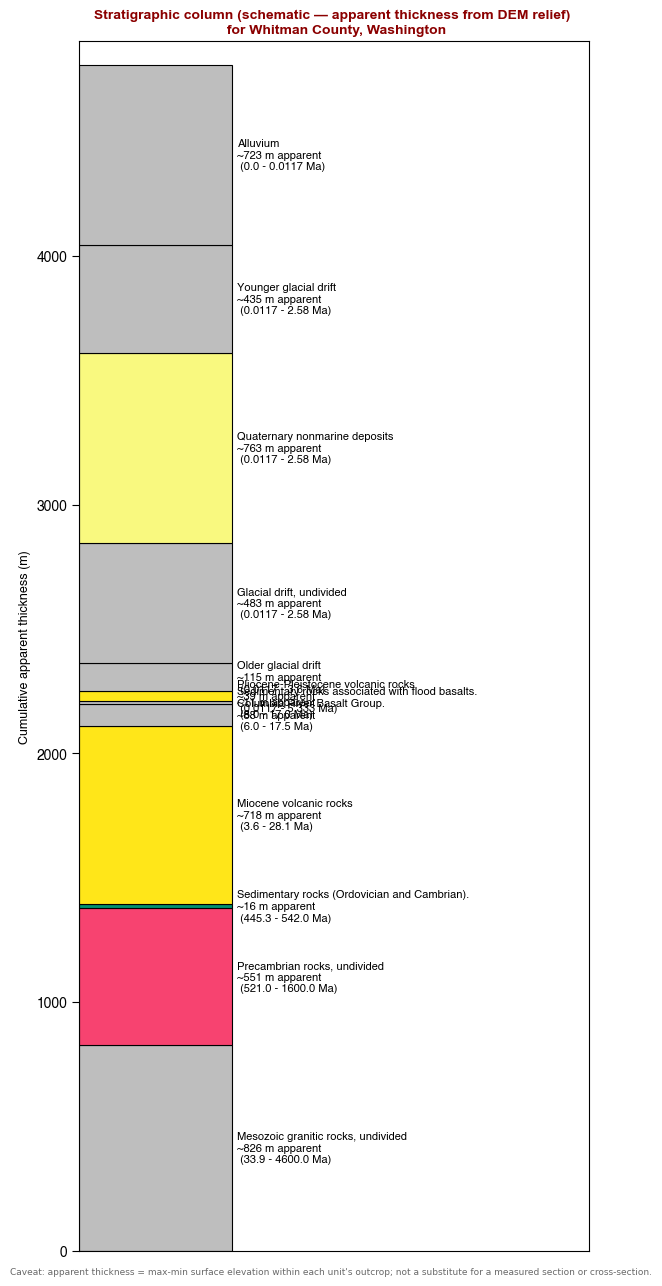

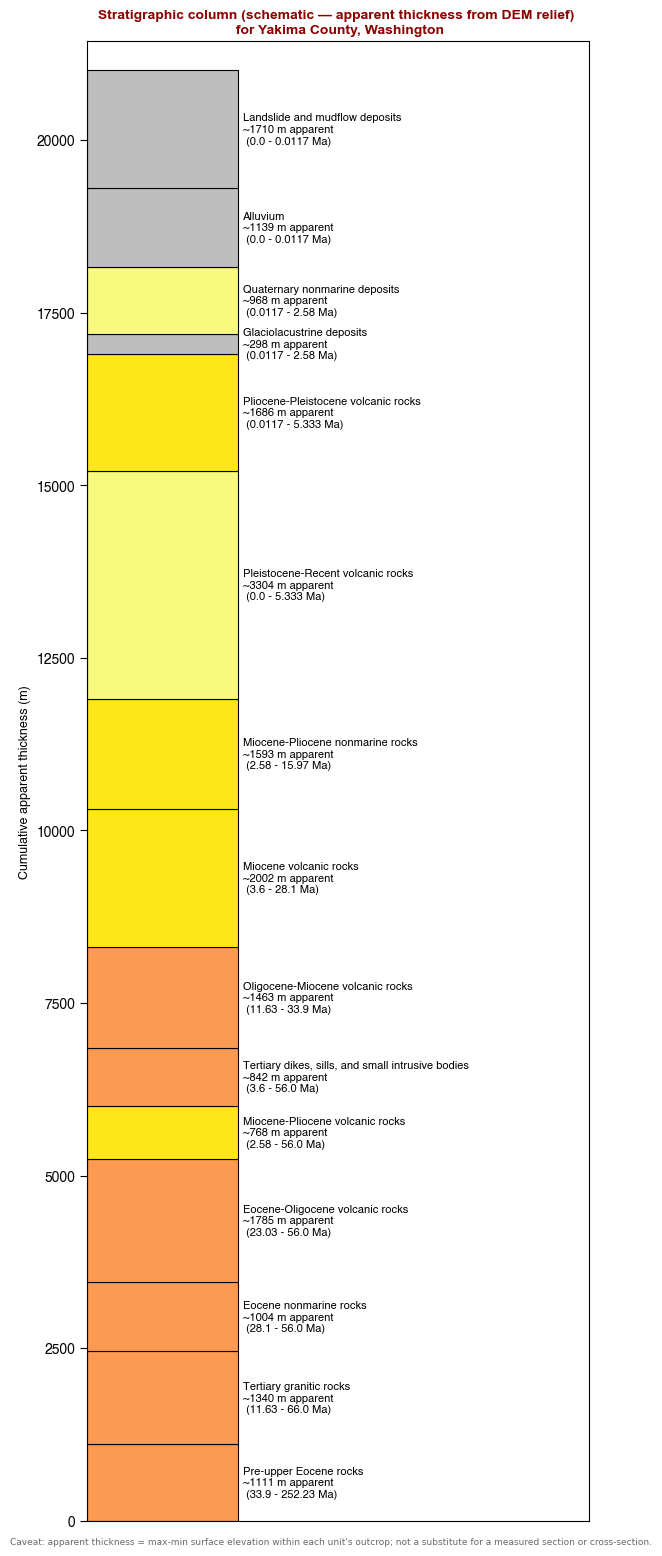

In [260]:
# Loop through all counties in a state and generate stratigraphic columns for each county

# Read counties TIGER shapefile
admin_dir = '/Users/ryanlennon/Library/CloudStorage/Dropbox/Administrative Boundaries'
counties_shp = os.path.join(admin_dir,'tl_rd22_us_county')
gdf_counties = gpd.read_file(counties_shp)
# Subset counties gdf to state
state_counties = gdf_counties[gdf_counties['STATEFP']==str(state_fips)]

county_list = list(state_counties['NAMELSAD'])
county_list.sort()

print('Counties in ' + state_name  + ' State include:')
for county_name in county_list:
    county = county_name
    county_fn = county.replace(" ", "") + '.shp'
    GeMS_fn = county.replace(" ", "") + '_GeMS.shp'
    DEM_fn = county + "_SRTM.tiff"
    SC_fn = county.replace(" ", "") + '_stratigraphy.png'
    CSV_fn = county.replace(" ", "") + '_stratigraphy.csv'
    # --- Required paths ---
    UNITS_SHAPEFILE = os.path.join(GeMS_dir,GeMS_fn)       # path to GeMS map-units polygon shapefile (.shp)
    units_shapefile = UNITS_SHAPEFILE
    DEM_PATH = os.path.join(srtm_state_dir,DEM_fn)                # path to DEM raster (e.g. GeoTIFF)
    output_png = os.path.join(SC_dir,SC_fn)  # where to save the column figure
    # --- Optional: also write the underlying data table ---
    csv_out = os.path.join(SC_dir,CSV_fn)  # set to None to skip writing a CSV
    if __name__ == "__main__":
        try:
            main()
        except Exception as exc:
            print(f"Error: {exc}", file=sys.stderr)
            sys.exit(1)
